# 02 -- Cohorts and Retention

Purchase retention (primary, per CLAUDE.md principle 1) and activity retention
(secondary) for the REES46 cosmetics shop, Oct 2019 - Feb 2020.

Inputs are inherited, not re-derived: the bot exclusion, the certified
order-reconstruction rule and the retention-horizon feasibility all come from
`outputs/handoff_params.json`. Section 0 first closes four items 01 left open, two of
which change how the rest of this notebook (and 04/05/08) must be read.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands
from src.data import connect, materialize, create_orders_view, key_round

SEED = 42
np.random.seed(SEED)
TABLES_DIR = os.path.join("outputs", "tables")
FIG_DIR = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as f:
    handoff = json.load(f)

BOT = handoff["bot_exclusion"]
print("Inherited from handoff_params.json (NOT re-derived):")
print(f"  bot exclusion: {BOT['metric']} > {BOT['threshold']}  ->  {BOT['n_users_excluded']:,} users")
print(f"  order rule   : {handoff['order_reconstruction_rule']['rule']}")
print(f"  primary horizon: D{handoff['retention_horizon']['primary_days']}")
print(f"  D30 feasible cohorts: {handoff['retention_horizon']['d30_feasible_cohorts']}")
print(f"  D60 feasible cohorts: {handoff['retention_horizon']['d60_feasible_cohorts']}")
print(f"  D90 feasible cohorts: {handoff['retention_horizon']['d90_feasible_cohorts']}")

con = connect()
print("\nDuckDB ready (threads=6; see src/data.py connect() for the determinism guardrails).")

Inherited from handoff_params.json (NOT re-derived):
  bot exclusion: sessions per active day (distinct user_session count / distinct active-day count) > 29.0  ->  1,605 users
  order rule   : GROUP BY (user_id, user_session, event_time) on event_type='purchase' rows
  primary horizon: D30
  D30 feasible cohorts: ['2019-10-01', '2019-11-01', '2019-12-01']
  D60 feasible cohorts: ['2019-10-01', '2019-11-01', '2019-12-01']
  D90 feasible cohorts: ['2019-10-01', '2019-11-01']

DuckDB ready (threads=6; see src/data.py connect() for the determinism guardrails).


In [2]:
t0 = time.time()
con.execute("CREATE OR REPLACE VIEW ev_raw AS SELECT * FROM read_csv_auto('data/raw/*.csv', filename=true)")
con.execute("CREATE OR REPLACE VIEW ev0 AS SELECT * FROM ev_raw WHERE user_session IS NOT NULL")

# Bot list is INHERITED: re-applied from the certified threshold, not re-derived.
BOT_THRESHOLD = float(BOT["threshold"])
con.execute(f"""
CREATE OR REPLACE VIEW bot_users AS
WITH u AS (SELECT user_id, count(DISTINCT user_session) n_sessions,
           count(DISTINCT date_trunc('day', event_time)) n_active_days FROM ev0 GROUP BY user_id)
SELECT user_id FROM u WHERE n_sessions*1.0/n_active_days > {BOT_THRESHOLD}
""")
n_bot = con.execute("SELECT count(*) FROM bot_users").fetchone()[0]
assert n_bot == BOT["n_users_excluded"], f"bot list drifted: {n_bot} vs {BOT['n_users_excluded']}"
print(f"Bot list re-applied from the certified threshold: {n_bot:,} users (matches handoff exactly)")

# Materialise: every relation below is referenced many times, and a lazy view over the
# raw CSVs re-scans 2.4GB per reference. See Section 0D for why this also matters for
# CORRECTNESS, not just speed.
materialize(con, "ev", "SELECT * FROM ev0 WHERE user_id NOT IN (SELECT user_id FROM bot_users)")
create_orders_view(con, events_view="ev", view_name="orders_v")
materialize(con, "orders", "SELECT * FROM orders_v")
materialize(con, "purch", "SELECT user_id, user_session, product_id, category_id, price, event_time FROM ev WHERE event_type='purchase'")

DATA_END = con.execute("SELECT max(event_time) FROM ev").fetchone()[0]
n_events = con.execute("SELECT count(*) FROM ev").fetchone()[0]
n_orders = con.execute("SELECT count(*) FROM orders").fetchone()[0]
n_purchasers = con.execute("SELECT count(DISTINCT user_id) FROM orders").fetchone()[0]
print(f"ev={n_events:,} rows | orders={n_orders:,} | purchasers={n_purchasers:,} | DATA_END={DATA_END} "
      f"[{time.time()-t0:.0f}s]")

Bot list re-applied from the certified threshold: 1,605 users (matches handoff exactly)


ev=20,327,652 rows | orders=158,399 | purchasers=109,732 | DATA_END=2020-02-29 23:59:59 [19s]


## Section 0 -- Closing four items carried forward from 01

01 ended with four open items. They are resolved here rather than in 01 because two of
them (0A, 0C) define segments that 04/05 consume, one (0B) decides how 08 may frame an
intervention, and one (0D) is a post-mortem on a bug that silently corrupted part of
01. Each is self-contained; the retention analysis proper starts at Section 1.

### 0D -- Post-mortem: what the DuckDB non-determinism actually was

01 was run single-threaded after two identical multi-threaded runs disagreed. That
workaround was treating the symptom. The cause, isolated here:

`removals_dedup` was a lazy **VIEW** carrying `row_number() OVER ()`. DuckDB
re-evaluates a view on every reference, and with no `ORDER BY` the id is assigned in
physical scan order, which differs per reference once the underlying relation is
itself a lazy chain over the raw CSVs. **99.97% of ids pointed at a different row
across two evaluations**, so every flag join landed on the wrong rows.

`threads=1` made that *reproducible* but not *correct* -- reproducibly wrong. Building
the classification four ways (materialised/lazy x threads 1/6) showed all four agree
once the underlying relation is materialised, and they agree with the materialised
result, not with 01's originally committed numbers. 01 has been re-run and corrected
(commit `85c92ae`); its abandonment conclusion reversed as a result.

**Scoped rule adopted** (so multi-threading is kept for the heavy scans):

| Operation | Deterministic at threads=6? | Action |
|---|---|---|
| `count(*)`, `count(DISTINCT)`, `min`/`max` | yes | none |
| `quantile_cont` (exact) | yes | none |
| window fn over a *materialised* table | yes | none |
| `row_number() OVER ()` in a lazy view | **no -- corrupts joins** | **materialise** |
| `approx_quantile` (sketch) | **no -- 4.0754 vs 4.0705** | **use `quantile_cont`** |
| raw float `sum`/`avg` | last ~7 sig figs | round at reporting precision |

A global `threads=1` was rejected: it costs ~3-4x wall clock on 20M rows and, as
shown, does not actually buy correctness.

In [3]:
# Guardrail 1 in force: this notebook's only synthetic-id relation, materialised.
# Guardrail 3: every order-sequence window function carries an explicit tiebreaker
# (order_ts, user_session) so row identity is fixed even when two orders share a second.
materialize(con, "first_order", """
    SELECT user_id, user_session AS first_session, order_ts AS first_ts,
           n_items AS first_n_items, order_value AS first_order_value
    FROM (SELECT *, row_number() OVER (PARTITION BY user_id ORDER BY order_ts, user_session) rn
          FROM orders) WHERE rn = 1
""")
n_first = con.execute("SELECT count(*) FROM first_order").fetchone()[0]
assert n_first == n_purchasers, (n_first, n_purchasers)
print(f"first_order built for {n_first:,} purchasers (one row per purchaser -- matches distinct purchasers)")

# Determinism spot-check, run in-notebook rather than asserted in prose.
chk = [con.execute("SELECT count(*), count(DISTINCT user_id), round(sum(first_order_value),2) FROM first_order").fetchone()
       for _ in range(2)]
print(f"determinism spot-check (same query twice): {chk[0]} == {chk[1]} -> {chk[0] == chk[1]}")

first_order built for 109,732 purchasers (one row per purchaser -- matches distinct purchasers)
determinism spot-check (same query twice): (109732, 109732, 4204691.35) == (109732, 109732, 4204691.35) -> True


### 0A -- What *is* `other_inconclusive`?

01 left 48.2% of abandonment events in a residual bucket that, after controlling for
abandonment volume, retained *better* than two of the four named types. Half the data
cannot stay "other", so it is broken down here by what the user actually did after the
removal.

Sub-types are assigned by the same priority-rule discipline 01 used, and are mutually
exclusive by construction:

1. **substitution_same_session** -- bought a *different* product in the *same category*, same session
2. **substitution_later_session** -- same, but in a later session
3. **recart_no_purchase** -- re-added the *same* product to cart, never bought it
4. **bought_other_category** -- bought something, but outside the removed item's category
5. **returned_browsed_only** -- came back to the category, bought nothing anywhere

In [4]:
t0 = time.time()
materialize(con, "removals_base", """
    SELECT DISTINCT user_id, user_session, product_id, category_id, price, event_time
    FROM ev WHERE event_type='remove_from_cart'""")
# ORDER BY the full DISTINCT key, not OVER (): an unordered row_number() numbers rows
# in physical scan order, so the ids move BETWEEN runs even after materialisation.
materialize(con, "removals", "SELECT *, row_number() OVER (ORDER BY user_id, user_session, product_id, category_id, round(price, 6), event_time) AS removal_id FROM removals_base")
materialize(con, "views_only", """
    SELECT user_id, user_session, category_id, product_id, price, event_time FROM ev WHERE event_type='view'""")
materialize(con, "prod_purch_max", "SELECT user_id, product_id, max(event_time) mx FROM purch GROUP BY 1,2")
materialize(con, "cat_max", "SELECT user_id, category_id, max(event_time) mx FROM ev GROUP BY 1,2")
materialize(con, "deferred_f", """
    SELECT DISTINCT r.removal_id FROM removals r
    JOIN prod_purch_max p ON r.user_id=p.user_id AND r.product_id=p.product_id
    WHERE p.mx > r.event_time""")
materialize(con, "price_f", """
    SELECT DISTINCT r.removal_id FROM removals r
    JOIN views_only v ON r.user_id=v.user_id AND r.user_session=v.user_session AND r.category_id=v.category_id
    WHERE v.event_time > r.event_time AND v.product_id != r.product_id AND v.price < r.price""")
materialize(con, "comp_c", """
    SELECT r.removal_id, count(DISTINCT v.product_id) n_alt FROM removals r
    JOIN views_only v ON r.user_id=v.user_id AND r.category_id=v.category_id
    WHERE v.event_time > r.event_time AND v.product_id != r.product_id GROUP BY 1""")

flags = con.execute("""
  SELECT r.removal_id, r.user_id, r.user_session, r.product_id, r.category_id, r.event_time,
    (d.removal_id IS NOT NULL) AS f_def, (p.removal_id IS NOT NULL) AS f_pri,
    (coalesce(c.n_alt,0) >= 3) AS f_cmp, (m.mx <= r.event_time) AS f_nev
  FROM removals r
  LEFT JOIN deferred_f d ON d.removal_id=r.removal_id
  LEFT JOIN price_f p ON p.removal_id=r.removal_id
  LEFT JOIN comp_c c ON c.removal_id=r.removal_id
  LEFT JOIN cat_max m ON r.user_id=m.user_id AND r.category_id=m.category_id
""").fetchdf()
NAMES = ["deferred_intent","price_driven","comparison_browse","true_abandonment"]
flags["atype"] = np.select([flags.f_def, flags.f_pri, flags.f_cmp, flags.f_nev], NAMES, default="other_inconclusive")
n_removals_total = len(flags)
print(f"reproduced 01's corrected classification over {n_removals_total:,} deduplicated removals [{time.time()-t0:.0f}s]")
print(flags["atype"].value_counts().to_string())

reproduced 01's corrected classification over 2,949,582 deduplicated removals [11s]
atype
other_inconclusive    1422387
true_abandonment       595344
comparison_browse      457746
price_driven           244626
deferred_intent        229479


In [5]:
t0 = time.time()
con.register("flags_df", flags)
materialize(con, "oth", """SELECT removal_id, user_id, user_session, product_id, category_id, event_time
                           FROM flags_df WHERE atype='other_inconclusive'""")
n_oth = con.execute("SELECT count(*) FROM oth").fetchone()[0]

sub = con.execute("""
  SELECT o.removal_id,
    max(CASE WHEN p.user_session  = o.user_session THEN 1 ELSE 0 END) AS sub_same_session,
    max(CASE WHEN p.user_session != o.user_session THEN 1 ELSE 0 END) AS sub_later_session
  FROM oth o JOIN purch p ON o.user_id=p.user_id AND o.category_id=p.category_id
  WHERE p.event_time > o.event_time AND p.product_id != o.product_id
  GROUP BY 1""").fetchdf()
recart = con.execute("""
  SELECT DISTINCT o.removal_id FROM oth o
  JOIN ev c ON o.user_id=c.user_id AND o.product_id=c.product_id
  WHERE c.event_type='cart' AND c.event_time > o.event_time""").fetchdf()
materialize(con, "user_purch_max", "SELECT user_id, max(event_time) mx FROM purch GROUP BY 1")
anybuy = con.execute("""
  SELECT o.removal_id FROM oth o JOIN user_purch_max u ON o.user_id=u.user_id
  WHERE u.mx > o.event_time""").fetchdf()

oth = con.execute("SELECT * FROM oth").fetchdf().merge(sub, on="removal_id", how="left")
oth[["sub_same_session","sub_later_session"]] = oth[["sub_same_session","sub_later_session"]].fillna(0).astype(int)
oth["recart"] = oth.removal_id.isin(set(recart.removal_id)).astype(int)
oth["bought_any"] = oth.removal_id.isin(set(anybuy.removal_id)).astype(int)
oth["subtype"] = np.select(
    [oth.sub_same_session==1, oth.sub_later_session==1, oth.recart==1, oth.bought_any==1],
    ["substitution_same_session","substitution_later_session","recart_no_purchase","bought_other_category"],
    default="returned_browsed_only")
print(f"sub-typed {len(oth):,} other_inconclusive removals [{time.time()-t0:.0f}s]")

st = oth.subtype.value_counts()
sub_tbl = pd.DataFrame({"n_events": st,
                        "pct_of_other": (100*st/n_oth).round(2),
                        "pct_of_all_removals": (100*st/n_removals_total).round(2)})
assert st.sum() == n_oth, "sub-types must partition other_inconclusive"
print(f"\nsub-types sum to {st.sum():,} == other_inconclusive {n_oth:,} (partition holds)")
show_df(sub_tbl.reset_index().rename(columns={"index":"subtype"}), name="nb02_other_inconclusive_subtypes")

sub-typed 1,422,387 other_inconclusive removals [2s]

sub-types sum to 1,422,387 == other_inconclusive 1,422,387 (partition holds)
                      subtype  n_events  pct_of_other  pct_of_all_removals
0       returned_browsed_only    590759         41.53                20.03
1       bought_other_category    333739         23.46                11.31
2  substitution_later_session    211611         14.88                 7.17
3   substitution_same_session    184251         12.95                 6.25
4          recart_no_purchase    102027          7.17                 3.46


,subtype,n_events,pct_of_other,pct_of_all_removals
0,returned_browsed_only,590759,41.53,20.03
1,bought_other_category,333739,23.46,11.31
2,substitution_later_session,211611,14.88,7.17
3,substitution_same_session,184251,12.95,6.25
4,recart_no_purchase,102027,7.17,3.46


In [6]:
opu = con.execute("SELECT user_id, count(*) n FROM orders GROUP BY 1").fetchdf().set_index("user_id")["n"]
repeat_users = set(opu[opu >= 2].index)
rows = []
for s in sub_tbl.index:
    us = set(oth.loc[oth.subtype == s, "user_id"])
    nr = len(us & repeat_users)
    lo, hi = proportion_confint(nr, len(us), method="wilson")
    rows.append((s, len(us), nr, 100*nr/len(us), 100*lo, 100*hi))
sub_rates = pd.DataFrame(rows, columns=["subtype","n_users","n_repeat","repeat_rate_pct","ci_lo","ci_hi"]
                         ).sort_values(["repeat_rate_pct", "subtype"], ascending=[False, True], kind="mergesort")
show_df(sub_rates, name="nb02_other_inconclusive_subtype_repeat_rates")

subst_events = int(sub_tbl.loc[["substitution_same_session","substitution_later_session"], "n_events"].sum())
print(f"\nSUBSTITUTION (same- + later-session) = {subst_events:,} events = "
      f"{100*subst_events/n_oth:.1f}% of other_inconclusive, {100*subst_events/n_removals_total:.1f}% of ALL removals.")
print("It is a single coherent behaviour -- the user did not abandon, they swapped to a different")
print("product in the same category -- and it retains at roughly double the rate of the residual.")
print(f"\nThe genuine leftover is `returned_browsed_only`: "
      f"{100*sub_tbl.loc['returned_browsed_only','n_events']/n_removals_total:.1f}% of all removals, "
      f"repeat rate {sub_rates.set_index('subtype').loc['returned_browsed_only','repeat_rate_pct']:.1f}% -- "
      "the LOWEST of any group here,")
print("i.e. it behaves like a softer form of true_abandonment rather than like a 'promising' bucket.")
print("\nPROMOTION (for 04): `substitution` becomes a named type; `returned_browsed_only` is the only")
print(f"bucket that stays residual, shrinking 'unclassified' from {100*n_oth/n_removals_total:.1f}% to "
      f"{100*sub_tbl.loc['returned_browsed_only','n_events']/n_removals_total:.1f}% of removals.")

                      subtype  n_users  n_repeat  repeat_rate_pct      ci_lo      ci_hi
2  substitution_later_session    32460     13727        42.288971  41.752491  42.827276
1       bought_other_category    37758     14974        39.657821  39.165475  40.152271
3   substitution_same_session    46849     16066        34.293155  33.864618  34.724267
4          recart_no_purchase    29358      5783        19.698208  19.247238  20.157107
0       returned_browsed_only    73614      4096         5.564159   5.400875   5.732080

SUBSTITUTION (same- + later-session) = 395,862 events = 27.8% of other_inconclusive, 13.4% of ALL removals.
It is a single coherent behaviour -- the user did not abandon, they swapped to a different
product in the same category -- and it retains at roughly double the rate of the residual.

The genuine leftover is `returned_browsed_only`: 20.0% of all removals, repeat rate 5.6% -- the LOWEST of any group here,
i.e. it behaves like a softer form of true_abandonment rat

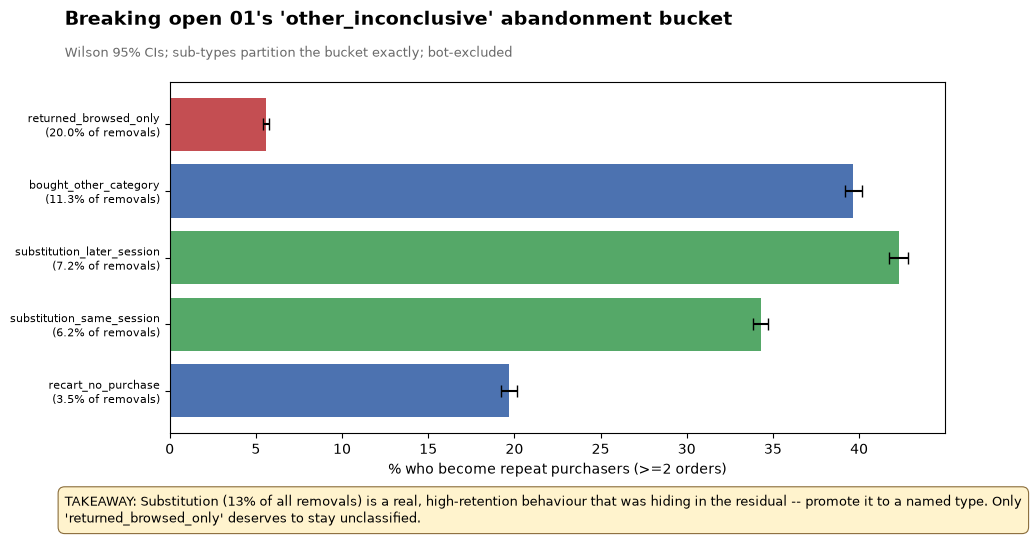

In [7]:
fig, ax = frame(figsize=(10, 5.5))
d = sub_rates.set_index("subtype").loc[sub_tbl.index.tolist()]
colors = ["#55A868" if "substitution" in s else "#C44E52" if s == "returned_browsed_only" else "#4C72B0"
          for s in d.index]
ax.barh(range(len(d)), d["repeat_rate_pct"],
        xerr=[d["repeat_rate_pct"]-d["ci_lo"], d["ci_hi"]-d["repeat_rate_pct"]],
        color=colors, capsize=4)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"{s}\n({sub_tbl.loc[s,'pct_of_all_removals']:.1f}% of removals)" for s in d.index], fontsize=8)
ax.set_xlabel("% who become repeat purchasers (>=2 orders)")
ax.invert_yaxis()
add_title(fig, "Breaking open 01's 'other_inconclusive' abandonment bucket",
          "Wilson 95% CIs; sub-types partition the bucket exactly; bot-excluded")
add_takeaway(fig, f"Substitution ({100*subst_events/n_removals_total:.0f}% of all removals) is a real, "
                   "high-retention behaviour that was hiding in the residual -- promote it to a named type. "
                   "Only 'returned_browsed_only' deserves to stay unclassified.")
save(fig, "nb02_0A_other_inconclusive_breakdown")
plt.show()

### 0E -- The abandonment-type ranking leaks the outcome

01 and Section 0A above both rank abandonment types by downstream repeat purchase,
and the ranking sorts almost perfectly by *how much purchasing each type's definition
already requires*:

| type | what the definition requires | reported OR |
|---|---|---|
| `deferred_intent` | a later purchase of the removed product | **10.81** |
| `substitution` | a purchase of a different product in the category | highest repeat rate |
| `price_driven` | only a *view* of a cheaper item | **1.00** (tied with baseline) |

That is not an effect size, it is close to a definitional identity: the "later
purchase" a type requires is unbounded in time, so it frequently *is* the repeat
purchase being predicted. `OR = 10.81 [10.29, 11.36]` is measuring the overlap
between a definition and an outcome.

**Fixed by temporal separation, not by redefinition.** The types keep their meaning;
only the windows change:

- **Classification window** = everything strictly *before* the user's first order.
  Every purchase a type definition references must fall inside this window -- and
  because the anchor is the *first* order, the only purchase available is that first
  order itself.
- **Outcome window** = strictly *after* the first order, `(t1, t1 + H]`, over eligible
  cohorts only.

The two windows are disjoint by construction, so no type definition can reach into the
outcome. `true_abandonment` is likewise bounded ("no return to the category before the
first order") rather than relying on an unbounded "never".

In [8]:
t0 = time.time()
materialize(con, "pre_rem_base", """
    SELECT DISTINCT r.user_id, r.user_session, r.product_id, r.category_id, r.price,
           r.event_time, f.first_ts
    FROM ev r JOIN first_order f USING (user_id)
    WHERE r.event_type='remove_from_cart' AND r.event_time < f.first_ts""")
# ORDER BY the full DISTINCT key, not OVER (): an unordered row_number() numbers rows
# in physical scan order, so the ids move BETWEEN runs even after materialisation.
materialize(con, "pre_rem", "SELECT *, row_number() OVER (ORDER BY user_id, user_session, product_id, category_id, round(price, 6), event_time) AS rid FROM pre_rem_base")
materialize(con, "v_pre", """
    SELECT user_id, user_session, category_id, product_id, price, event_time
    FROM ev WHERE event_type='view'""")

# Every referenced purchase is bounded by <= first_ts: inside the classification window.
materialize(con, "f_deferred", """
    SELECT DISTINCT r.rid FROM pre_rem r JOIN purch p
      ON r.user_id=p.user_id AND r.product_id=p.product_id
    WHERE p.event_time > r.event_time AND p.event_time <= r.first_ts""")
materialize(con, "f_subst", """
    SELECT DISTINCT r.rid FROM pre_rem r JOIN purch p
      ON r.user_id=p.user_id AND r.category_id=p.category_id
    WHERE p.product_id <> r.product_id AND p.event_time > r.event_time AND p.event_time <= r.first_ts""")
materialize(con, "f_price", """
    SELECT DISTINCT r.rid FROM pre_rem r JOIN v_pre v
      ON r.user_id=v.user_id AND r.user_session=v.user_session AND r.category_id=v.category_id
    WHERE v.event_time > r.event_time AND v.event_time <= r.first_ts
      AND v.product_id <> r.product_id AND v.price < r.price""")
materialize(con, "f_comp", """
    SELECT r.rid, count(DISTINCT v.product_id) n_alt FROM pre_rem r JOIN v_pre v
      ON r.user_id=v.user_id AND r.category_id=v.category_id
    WHERE v.event_time > r.event_time AND v.event_time <= r.first_ts AND v.product_id <> r.product_id
    GROUP BY 1""")
materialize(con, "f_ret", """
    SELECT DISTINCT r.rid FROM pre_rem r JOIN ev e
      ON r.user_id=e.user_id AND r.category_id=e.category_id
    WHERE e.event_time > r.event_time AND e.event_time <= r.first_ts""")

fl = con.execute("""
  SELECT r.rid, r.user_id,
    (d.rid IS NOT NULL) f_def, (s.rid IS NOT NULL) f_sub, (p.rid IS NOT NULL) f_pri,
    (coalesce(c.n_alt,0) >= 3) f_cmp, (ret.rid IS NULL) f_never
  FROM pre_rem r
  LEFT JOIN f_deferred d USING (rid) LEFT JOIN f_subst s USING (rid)
  LEFT JOIN f_price p USING (rid) LEFT JOIN f_comp c USING (rid) LEFT JOIN f_ret ret USING (rid)
""").fetchdf()
LEAK_NAMES = ["deferred_intent","substitution","price_driven","comparison_browse","true_abandonment"]
fl["atype"] = np.select([fl.f_def, fl.f_sub, fl.f_pri, fl.f_cmp, fl.f_never],
                        LEAK_NAMES, default="other_inconclusive")
n_pre_users = fl.user_id.nunique()
print(f"Classification window = events strictly before the first order.")
print(f"  {len(fl):,} pre-first-order removals across {n_pre_users:,} users "
      f"({100*n_pre_users/n_purchasers:.1f}% of {n_purchasers:,} purchasers) [{time.time()-t0:.0f}s]")

ua = fl.groupby("user_id").agg(
    any_def=("f_def","any"), any_sub=("f_sub","any"), any_pri=("f_pri","any"),
    any_cmp=("f_cmp","any"), any_never=("f_never","any"), n_rem=("rid","count")).reset_index()
ua["utype"] = np.select([ua.any_def, ua.any_sub, ua.any_pri, ua.any_cmp, ua.any_never],
                        LEAK_NAMES, default="other_inconclusive")
assert ua.utype.value_counts().sum() == n_pre_users
print(f"\nUser-level exclusive types (same priority discipline as 01), summing to {n_pre_users:,}:")
print(ua.utype.value_counts().to_string())

Classification window = events strictly before the first order.
  1,073,211 pre-first-order removals across 83,239 users (75.9% of 109,732 purchasers) [9s]



User-level exclusive types (same priority discipline as 01), summing to 83,239:
utype
deferred_intent       44947
substitution          30408
true_abandonment       7282
price_driven            344
comparison_browse       133
other_inconclusive      125


In [9]:
import statsmodels.formula.api as smf

# Self-contained eligibility (0E sits before Section 1, which builds cohort_elig).
elig_leak = con.execute(f"""
  SELECT date_trunc('month', first_ts) AS cohort_month,
         date_diff('second', max(first_ts), TIMESTAMP '{DATA_END}')/86400.0 AS min_trailing_days
  FROM first_order GROUP BY 1""").fetchdf()

outc_leak = con.execute("""
  SELECT f.user_id, date_trunc('month', f.first_ts) cohort_month,
         min(date_diff('second', f.first_ts, o.order_ts)/86400.0) AS days_to_next
  FROM first_order f LEFT JOIN orders o
    ON f.user_id=o.user_id AND o.order_ts > f.first_ts AND o.user_session <> f.first_session
  GROUP BY 1,2""").fetchdf()
dl = ua.merge(outc_leak, on="user_id", how="left").merge(elig_leak, on="cohort_month", how="left")

leak_results = {}
for H in (30, 60):
    sub = dl[dl.min_trailing_days >= H].copy()
    sub["repeat"] = (sub.days_to_next <= H).astype(int)
    rows = []
    for t, g in sub.groupby("utype"):
        k = int(g["repeat"].sum()); n = len(g)
        lo, hi = proportion_confint(k, n, method="wilson")
        rows.append((t, n, k, 100*k/n, 100*lo, 100*hi, float(g.n_rem.median())))
    tab = pd.DataFrame(rows, columns=["type","n_users","n_repeat","repeat_pct","ci_lo","ci_hi",
                                      "median_n_removals"]).sort_values(
            ["repeat_pct", "type"], ascending=[False, True], kind="mergesort")
    assert tab.n_users.sum() == len(sub)
    sub["log_n"] = np.log1p(sub.n_rem)
    m = smf.logit('repeat ~ C(utype, Treatment(reference="true_abandonment")) + log_n',
                  data=sub).fit(disp=0)
    ors = pd.DataFrame({"OR": np.exp(m.params), "ci_lo": np.exp(m.conf_int()[0]),
                        "ci_hi": np.exp(m.conf_int()[1]), "p": m.pvalues})
    ors = ors[ors.index.str.contains("utype") | (ors.index == "log_n")]
    ors.index = [i.split("T.")[-1].rstrip("]") if "T." in i else i for i in ors.index]
    leak_results[H] = dict(tab=tab, ors=ors, n=len(sub))
    print(f"\n=== OUTCOME WINDOW (t1, t1+{H}d], eligible cohorts only, n={len(sub):,} ===")
    show_df(tab.round(2), name=f"nb02_0E_leakage_safe_rates_D{H}")
    show_df(ors.round(3).reset_index().rename(columns={"index":"term"}),
            name=f"nb02_0E_leakage_safe_odds_D{H}")


=== OUTCOME WINDOW (t1, t1+30d], eligible cohorts only, n=54,836 ===
                 type  n_users  n_repeat  repeat_pct  ci_lo  ci_hi  median_n_removals
0   comparison_browse       90        25       27.78  19.58  37.80                8.5
3        price_driven      228        50       21.93  17.05  27.74                7.0
1     deferred_intent    29416      4707       16.00  15.59  16.42                8.0
4        substitution    20150      2985       14.81  14.33  15.31                4.0
5    true_abandonment     4876       704       14.44  13.48  15.45                2.0
2  other_inconclusive       76         9       11.84   6.36  21.00                1.0
                 term     OR  ci_lo  ci_hi      p
0   comparison_browse  1.605  1.001  2.573  0.050
1     deferred_intent  0.777  0.710  0.851  0.000
2  other_inconclusive  0.911  0.452  1.835  0.794
3        price_driven  1.172  0.845  1.626  0.341
4        substitution  0.838  0.766  0.918  0.000
5               log_n  1.378

In [10]:
o30 = leak_results[30]["ors"].drop("log_n")
vol30 = leak_results[30]["ors"].loc["log_n"]
LEAKY_DEFERRED_OR = 10.81
print("WHAT HAPPENED TO THE RANKING")
print("="*78)
def_or = o30.loc["deferred_intent"]
print(f"deferred_intent OR: {LEAKY_DEFERRED_OR:.2f} under the leaky spec  ->  "
      f"{def_or.OR:.2f} [{def_or.ci_lo:.2f}, {def_or.ci_hi:.2f}] once the windows are disjoint.")
print(f"That is a {LEAKY_DEFERRED_OR/def_or.OR:.0f}x collapse, and it crosses 1.0: the type that looked")
print("like the strongest positive signal is now BELOW the true_abandonment baseline.")
print()
print(f"Full type range after separation: OR {o30.OR.min():.2f} - {o30.OR.max():.2f} "
      f"(was 1.00 - {LEAKY_DEFERRED_OR:.2f}).")
sig_types = o30[(o30.ci_lo > 1) | (o30.ci_hi < 1)]
ns_types = o30[(o30.ci_lo <= 1) & (o30.ci_hi >= 1)]
print(f"Types whose CI excludes 1.0: {', '.join(sig_types.index) if len(sig_types) else 'none'}")
print(f"Types indistinguishable from baseline: {', '.join(ns_types.index) if len(ns_types) else 'none'}")
print()
print(f"Meanwhile abandonment VOLUME survives intact: log1p(n_removals) OR = {vol30.OR:.2f} "
      f"[{vol30.ci_lo:.2f}, {vol30.ci_hi:.2f}].")
print()
print("VERDICT: the hypothesised ordering (deferred_intent highest, price_driven lowest) DOES NOT")
print("SURVIVE temporal separation -- it inverts. deferred_intent and substitution, the two types whose")
print("definitions required a purchase, both fall BELOW the baseline once that purchase is confined to")
print("the classification window. The two types nominally above baseline (comparison_browse,")
print(f"price_driven) rest on {int(leak_results[30]['tab'].set_index('type').loc['comparison_browse','n_users'])} and "
      f"{int(leak_results[30]['tab'].set_index('type').loc['price_driven','n_users'])} users respectively, with CIs that all but touch 1.0.")
print()
print("So: abandonment TYPE carries little independent signal about repeat purchase. Abandonment")
print("VOLUME does. 01's and 0A's rankings measured the definitions, not the customers.")
print()
print("A caution against over-reading the inversion: deferred_intent sitting below baseline is not")
print("evidence that resolving hesitation HURTS retention. These users bought the specific item they")
print("had hesitated over, i.e. their stated need was met at the first order, while the baseline group")
print("is still carrying unmet demand. That is a plausible mechanism, not a demonstrated one, and the")
print("groups still differ in ways the volume control cannot absorb (median removals "
      f"{leak_results[30]['tab'].set_index('type').loc['deferred_intent','median_n_removals']:.0f} vs "
      f"{leak_results[30]['tab'].set_index('type').loc['true_abandonment','median_n_removals']:.0f}).")

WHAT HAPPENED TO THE RANKING
deferred_intent OR: 10.81 under the leaky spec  ->  0.78 [0.71, 0.85] once the windows are disjoint.
That is a 14x collapse, and it crosses 1.0: the type that looked
like the strongest positive signal is now BELOW the true_abandonment baseline.

Full type range after separation: OR 0.78 - 1.60 (was 1.00 - 10.81).
Types whose CI excludes 1.0: comparison_browse, deferred_intent, substitution
Types indistinguishable from baseline: other_inconclusive, price_driven

Meanwhile abandonment VOLUME survives intact: log1p(n_removals) OR = 1.38 [1.35, 1.41].

VERDICT: the hypothesised ordering (deferred_intent highest, price_driven lowest) DOES NOT
SURVIVE temporal separation -- it inverts. deferred_intent and substitution, the two types whose
definitions required a purchase, both fall BELOW the baseline once that purchase is confined to
the classification window. The two types nominally above baseline (comparison_browse,
price_driven) rest on 90 and 228 users respect

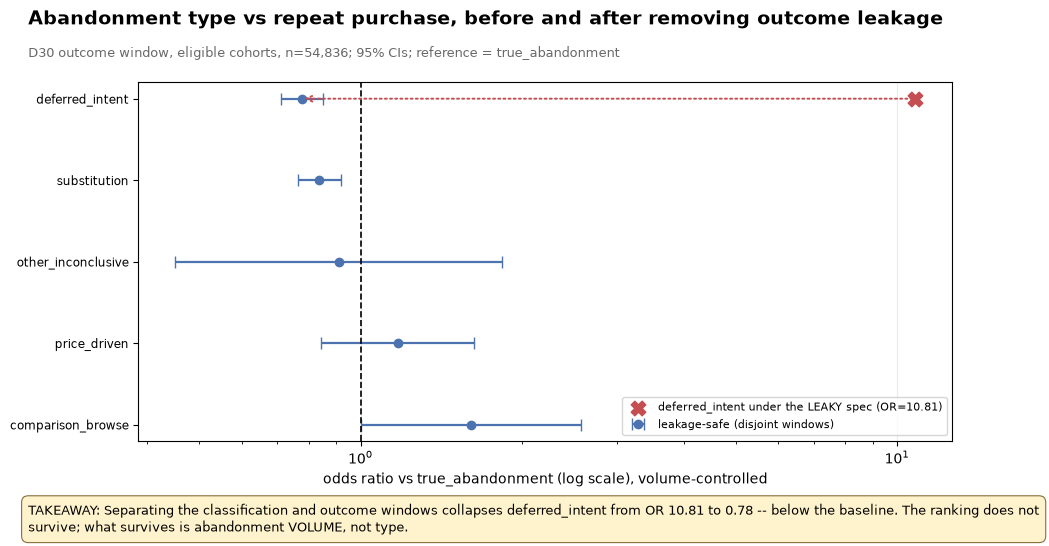

In [11]:
fig, ax = frame(figsize=(10.5, 5.6))
order = ["comparison_browse","price_driven","other_inconclusive","true_abandonment","substitution","deferred_intent"]
order = [t for t in order if t in o30.index]
y = np.arange(len(order))
vals = o30.loc[order]
ax.errorbar(vals.OR, y, xerr=[vals.OR-vals.ci_lo, vals.ci_hi-vals.OR], fmt="o", color="#4C72B0",
            capsize=4, lw=1.6, label="leakage-safe (disjoint windows)")
ax.axvline(1.0, color="black", ls="--", lw=1.2)
ax.scatter([LEAKY_DEFERRED_OR], [order.index("deferred_intent")], marker="X", s=110, color="#C44E52",
           zorder=5, label=f"deferred_intent under the LEAKY spec (OR={LEAKY_DEFERRED_OR})")
ax.annotate("", xy=(o30.loc["deferred_intent","OR"], order.index("deferred_intent")),
            xytext=(LEAKY_DEFERRED_OR, order.index("deferred_intent")),
            arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.4, ls=":"))
ax.set_yticks(y); ax.set_yticklabels(order, fontsize=8.5)
ax.set_xscale("log"); ax.set_xlabel("odds ratio vs true_abandonment (log scale), volume-controlled")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25, axis="x")
add_title(fig, "Abandonment type vs repeat purchase, before and after removing outcome leakage",
          f"D30 outcome window, eligible cohorts, n={leak_results[30]['n']:,}; 95% CIs; reference = true_abandonment")
add_takeaway(fig, f"Separating the classification and outcome windows collapses deferred_intent from "
                   f"OR {LEAKY_DEFERRED_OR} to {def_or.OR:.2f} -- below the baseline. The ranking does not survive; "
                   "what survives is abandonment VOLUME, not type.")
save(fig, "nb02_0E_leakage_safe_comparison")
plt.show()

### 0B -- "Loyalty compounds", or selection?

01 found P(3rd purchase | reached 2nd) runs ~1.8-2.0x P(2nd | 1st) and read it as
compounding. There is a competing explanation: the people who reach a 2nd purchase are
not a random draw -- they are enriched in high-propensity buyers, so the elevation
could be pure composition with no state dependence at all.

The two make different predictions. Under **pure selection**, time-to-2nd is a visible
proxy for latent propensity, so P(3rd) should fall steeply as time-to-2nd lengthens.
Under **compounding**, the act of buying twice lifts everyone, so even the slowest
2nd-purchasers should sit clearly above the P(2nd|1st) baseline.

Measured with Kaplan-Meier from the 2nd purchase (so the unequal remaining window
across buckets is handled as censoring, not as failure).

In [12]:
o = con.execute("SELECT user_id, order_ts, user_session FROM orders ORDER BY user_id, order_ts, user_session").fetchdf()
o["seq"] = o.groupby("user_id").cumcount()
t1s = o[o.seq==0].set_index("user_id")["order_ts"]
t2s = o[o.seq==1].set_index("user_id")["order_ts"]
t3s = o[o.seq==2].set_index("user_id")["order_ts"]
dd = pd.DataFrame({"t1": t1s}).join(t2s.rename("t2")).join(t3s.rename("t3"))
dd = dd[dd.t2.notna()].copy()
dd["days_1_2"] = (dd.t2 - dd.t1).dt.total_seconds()/86400
dd["event3"] = dd.t3.notna().astype(int)
dd["dur3"] = np.where(dd.event3==1, (dd.t3-dd.t2).dt.total_seconds()/86400,
                      (DATA_END - dd.t2).dt.total_seconds()/86400)

BASELINE_2ND_30D = 14.84   # from 01 lifecycle_rates.csv (KM, all purchasers)
labels = ["<=7d","8-21d","22-45d","46-90d",">90d"]
# RC-1: days_1_2 is a float cut against fixed integer edges -- a value sitting on 7.0 or
# 21.0 could fall either side on a last-bit wobble. Round the KEY, not the data.
dd["t2_bucket"] = pd.cut(key_round(dd.days_1_2), [0,7,21,45,90,1e9], labels=labels, include_lowest=True)

rows = []
for b in labels:
    s = dd[dd.t2_bucket == b]
    k = KaplanMeierFitter().fit(s.dur3, s.event3)
    ci = k.confidence_interval_survival_function_
    idx = ci.index[ci.index <= 30]
    lo, hi = (100*(1-ci.loc[idx[-1]].iloc[1]), 100*(1-ci.loc[idx[-1]].iloc[0])) if len(idx) else (np.nan, np.nan)
    p30 = 100*(1-k.survival_function_at_times(30).iloc[0])
    p60 = 100*(1-k.survival_function_at_times(60).iloc[0])
    rows.append((b, len(s), int(s.event3.sum()), p30, lo, hi, p60, p30/BASELINE_2ND_30D))
B = pd.DataFrame(rows, columns=["t2_bucket","n_users","n_reached_3rd","P3rd_by30d","ci_lo","ci_hi",
                                "P3rd_by60d","ratio_vs_baseline"])
assert B.n_users.sum() == len(dd), "t2 buckets must partition the 2nd-purchase population"
print(f"t2 buckets partition the {len(dd):,} users who reached a 2nd purchase: {B.n_users.sum():,}")
show_df(B.round(2), name="nb02_0B_compounding_vs_selection")

spread = B.P3rd_by30d.max() - B.P3rd_by30d.min()
slowest = B.iloc[-1]
print(f"\nBaseline P(2nd by 30d | 1st) = {BASELINE_2ND_30D}%  (denominator: all {n_purchasers:,} purchasers)")
print(f"Spread across time-to-2nd buckets at D30: {spread:.1f} pp "
      f"({B.P3rd_by30d.min():.1f}% -> {B.P3rd_by30d.max():.1f}%)")
print(f"Slowest bucket ({slowest.t2_bucket}, n={int(slowest.n_users):,}): P(3rd by 30d) = {slowest.P3rd_by30d:.1f}%, "
      f"{slowest.ratio_vs_baseline:.2f}x baseline (95% CI [{slowest.ci_lo:.1f}, {slowest.ci_hi:.1f}])")
print()
selection_dominant = spread > (slowest.P3rd_by30d - BASELINE_2ND_30D)
print("VERDICT: " + ("SELECTION dominates." if selection_dominant else "COMPOUNDING dominates."))
print(f"  The {spread:.1f}pp swing driven purely by *which* 2nd-purchasers you look at is larger than the")
print(f"  {slowest.P3rd_by30d - BASELINE_2ND_30D:.1f}pp floor that survives in the slowest bucket. Most of 01's ~2x")
print("  is composition: reaching a 2nd purchase identifies high-propensity buyers, it does not create them.")
print(f"  A real but modest residual elevation remains ({slowest.ratio_vs_baseline:.2f}x baseline even for the")
print("  slowest bucket, CI excludes the baseline), so state dependence is not zero -- it is just not the")
print("  main story.")
print()
print("CONSEQUENCE FOR 08: an intervention that manufactures a 2nd purchase should NOT be assumed to")
print(f"inherit the ~2x rate -- that rate belongs to users who were already going to buy. The defensible")
print(f"planning number is the residual ({slowest.ratio_vs_baseline:.2f}x), not the headline ratio.")
print("NOTE: buckets also differ in calendar position (a >90d gap requires an early first purchase), so")
print("the slowest bucket is drawn from earlier cohorts. KM handles the unequal window; it cannot handle")
print("that confound, which is why the residual is stated as an upper bound on compounding.")

t2 buckets partition the 24,731 users who reached a 2nd purchase: 24,731
  t2_bucket  n_users  n_reached_3rd  P3rd_by30d  ci_lo  ci_hi  P3rd_by60d  ratio_vs_baseline
0      <=7d     6950           2698       29.67  28.57  30.79       38.47               2.00
1     8-21d     5561           2765       35.71  34.41  37.04       50.60               2.41
2    22-45d     6217           2906       28.12  26.96  29.31       47.18               1.89
3    46-90d     4693           1423       20.91  19.69  22.19       38.76               1.41
4      >90d     1310            203       18.83  16.32  21.67       29.43               1.27

Baseline P(2nd by 30d | 1st) = 14.84%  (denominator: all 109,732 purchasers)
Spread across time-to-2nd buckets at D30: 16.9 pp (18.8% -> 35.7%)
Slowest bucket (>90d, n=1,310): P(3rd by 30d) = 18.8%, 1.27x baseline (95% CI [16.3, 21.7])

VERDICT: SELECTION dominates.
  The 16.9pp swing driven purely by *which* 2nd-purchasers you look at is larger than the
  4.0pp flo

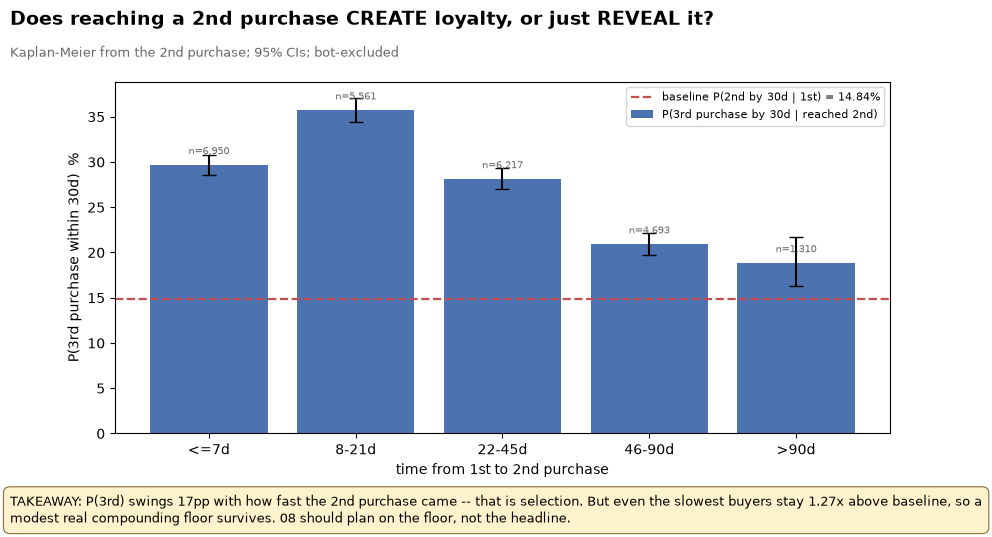

In [13]:
fig, ax = frame(figsize=(10, 5.5))
x = np.arange(len(B))
ax.bar(x, B.P3rd_by30d, yerr=[B.P3rd_by30d-B.ci_lo, B.ci_hi-B.P3rd_by30d],
       color="#4C72B0", capsize=5, label="P(3rd purchase by 30d | reached 2nd)")
ax.axhline(BASELINE_2ND_30D, color="#C44E52", linestyle="--", linewidth=1.6,
           label=f"baseline P(2nd by 30d | 1st) = {BASELINE_2ND_30D}%")
ax.set_xticks(x); ax.set_xticklabels(B.t2_bucket)
ax.set_xlabel("time from 1st to 2nd purchase")
ax.set_ylabel("P(3rd purchase within 30d)  %")
ax.legend(fontsize=8)
for xi, (n, v) in enumerate(zip(B.n_users, B.P3rd_by30d)):
    ax.text(xi, v+1.2, f"n={n:,}", ha="center", fontsize=7, color="dimgray")
add_title(fig, "Does reaching a 2nd purchase CREATE loyalty, or just REVEAL it?",
          "Kaplan-Meier from the 2nd purchase; 95% CIs; bot-excluded")
add_takeaway(fig, f"P(3rd) swings {spread:.0f}pp with how fast the 2nd purchase came -- that is selection. "
                   f"But even the slowest buyers stay {slowest.ratio_vs_baseline:.2f}x above baseline, so a "
                   "modest real compounding floor survives. 08 should plan on the floor, not the headline.")
save(fig, "nb02_0B_compounding_vs_selection")
plt.show()

### 0C -- The order-size tail: resellers, or an anomaly to clean?

01 established the heavy order-size tail is *not* the bot population (zero overlap).
This profiles those users directly and decides their treatment for 04/05.

In [14]:
BULK_ITEMS = con.execute("SELECT quantile_cont(n_items, 0.999) FROM orders").fetchone()[0]
print(f"Bulk-order threshold = exact P99.9 of order size = {BULK_ITEMS:.0f} items (data-derived, not rounded)")
materialize(con, "bulk_users", f"SELECT DISTINCT user_id FROM orders WHERE n_items >= {BULK_ITEMS}")
n_bulk = con.execute("SELECT count(*) FROM bulk_users").fetchone()[0]

prof = con.execute("""
WITH lines AS (SELECT user_id, count(*) n_lines, count(DISTINCT product_id) n_products,
                      count(DISTINCT category_id) n_categories, quantile_cont(price,0.5) med_price,
                      round(sum(price),2) total_spend FROM purch GROUP BY 1),
ords AS (SELECT user_id, count(*) n_orders, quantile_cont(n_items,0.5) med_items FROM orders GROUP BY 1),
act AS (SELECT user_id, count(DISTINCT date_trunc('day',event_time)) n_active_days FROM ev GROUP BY 1)
SELECT CASE WHEN b.user_id IS NOT NULL THEN 'bulk' ELSE 'typical' END AS segment,
       count(*) AS n_users,
       round(quantile_cont(o.n_orders,0.5),1) AS med_orders,
       round(quantile_cont(l.n_products,0.5),1) AS med_distinct_products,
       round(quantile_cont(l.n_categories,0.5),1) AS med_distinct_categories,
       round(quantile_cont(o.med_items,0.5),1) AS med_items_per_order,
       round(quantile_cont(l.med_price,0.5),2) AS med_item_price,
       round(quantile_cont(l.total_spend,0.5),2) AS med_total_spend,
       round(quantile_cont(a.n_active_days,0.5),1) AS med_active_days,
       round(100.0*avg(CASE WHEN o.n_orders>=2 THEN 1 ELSE 0 END),1) AS pct_repeat
FROM ords o JOIN lines l USING (user_id) JOIN act a USING (user_id)
LEFT JOIN bulk_users b USING (user_id) GROUP BY 1 ORDER BY 1
""").fetchdf()
show_df(prof, name="nb02_0C_bulk_buyer_profile")

share = con.execute("""
SELECT round(100.0*count(*) FILTER (WHERE b.user_id IS NOT NULL)/count(*),3) AS pct_of_orders,
       round(100.0*sum(o.order_value) FILTER (WHERE b.user_id IS NOT NULL)/sum(o.order_value),3) AS pct_of_revenue,
       round(100.0*sum(o.n_items) FILTER (WHERE b.user_id IS NOT NULL)/sum(o.n_items),3) AS pct_of_items
FROM orders o LEFT JOIN bulk_users b USING (user_id)
""").fetchdf()
show_df(share, name="nb02_0C_bulk_share_of_business")

p = prof.set_index("segment")
print(f"\n{n_bulk} users ({100*n_bulk/n_purchasers:.2f}% of purchasers) clear the {BULK_ITEMS:.0f}-item bar.")
print(f"Signature: median {p.loc['bulk','med_distinct_products']:.0f} distinct products across "
      f"{p.loc['bulk','med_distinct_categories']:.0f} categories, {p.loc['bulk','med_items_per_order']:.0f} items/order,")
print(f"at a LOWER median unit price ({p.loc['bulk','med_item_price']:.2f} vs {p.loc['typical','med_item_price']:.2f}) "
      f"and {p.loc['bulk','med_total_spend']/p.loc['typical','med_total_spend']:.0f}x the spend "
      f"({p.loc['bulk','med_total_spend']:.0f} vs {p.loc['typical','med_total_spend']:.0f}),")
print(f"with a median of {p.loc['bulk','med_orders']:.0f} order(s) and {p.loc['bulk','pct_repeat']:.0f}% repeating "
      f"(vs {p.loc['typical','pct_repeat']:.0f}%).")
print()
print("READ: breadth + volume + BELOW-average unit price + one big haul is a stock-up signature, not a")
print("consumer one. A shopper buying for themselves does not take 130 distinct SKUs across 31 categories")
print("in a single order. These look like resellers / salon or studio buyers -- a real B2B-ish segment,")
print("not dirty data. They are NOT removed.")
print()
print("DECISION for 04/05 (recorded in handoff_params.json):")
print(f"  - KEEP them: they are genuine customers and only {share.pct_of_revenue.iloc[0]:.2f}% of revenue, so")
print("    removing them would misstate the customer base to fix a statistic.")
print("  - FLAG them: persisted as `is_bulk_buyer` in data/processed/cohort_assignments.parquet, to be")
print("    carried as a named segment in 04's segmentation rather than discovered again as an outlier.")
print("  - EXCLUDE from MEAN-based monetary metrics in 04/05 (AOV, mean CLV, mean basket): 0.13% of")
print("    purchasers holding 1.4% of revenue with a 14x median basket will move a mean and not a median.")
print("    Report medians/winsorised means as headline, and report the bulk segment separately.")

Bulk-order threshold = exact P99.9 of order size = 91 items (data-derived, not rounded)


   segment  n_users  med_orders  med_distinct_products  med_distinct_categories  med_items_per_order  med_item_price  med_total_spend  med_active_days  \
0     bulk      143         1.0                  130.0                     31.0                 99.0            2.48           469.41              6.0   
1  typical   109589         1.0                    6.0                      4.0                  5.0            4.11            33.02              3.0   

   pct_repeat  
0        44.1  
1        22.5  
   pct_of_orders  pct_of_revenue  pct_of_items
0          0.193           1.445         1.936

143 users (0.13% of purchasers) clear the 91-item bar.
Signature: median 130 distinct products across 31 categories, 99 items/order,
at a LOWER median unit price (2.48 vs 4.11) and 14x the spend (469 vs 33),
with a median of 1 order(s) and 44% repeating (vs 22%).

READ: breadth + volume + BELOW-average unit price + one big haul is a stock-up signature, not a
consumer one. A shopper buying fo

## 1-2. Retention curves, with censoring made visible

**Cohort** = calendar month of a user's first order (bot-excluded, certified order rule).

**Both curves share one denominator and one clock.** For a user whose first order is at
`t1` in session `s1`, measured over the window `(t1, t1 + x days]`:

- **Purchase retention** -- placed >=1 further order, in a session other than `s1`
- **Activity retention** -- generated >=1 event of any type, in a session other than `s1`

Excluding `s1` from both is what makes this *retention* ("did they come back") rather
than "did they keep clicking after checkout", and it guarantees purchase retention is a
strict subset of activity retention, so the gap between the curves is always readable as
*came back but did not buy*. The count of repeat orders this rule excludes (a 2nd order
inside the first session) is reported below so the choice is auditable.

**Eligibility.** A cohort may only contribute to bucket Dx if *every* member has at
least x days of trailing data. Ineligible cohort/bucket cells are excluded from the
pooled rate entirely -- never averaged in as zeros -- and the eligible N is annotated
directly on the figure.

In [15]:
# Days of trailing window available to the LAST user to join each cohort.
cohort_elig = con.execute(f"""
    SELECT date_trunc('month', first_ts) AS cohort_month,
           count(*) AS n_users,
           date_diff('day', max(first_ts), TIMESTAMP '{DATA_END}') AS min_trailing_days
    FROM first_order GROUP BY 1 ORDER BY 1
""").fetchdf()
BUCKETS = [1, 3, 7, 14, 30, 60, 90]
for b in BUCKETS:
    cohort_elig[f"D{b}"] = cohort_elig.min_trailing_days >= b
show_df(cohort_elig, name="nb02_cohort_eligibility")

# --- AUDIT: is the Dec cohort really D60-eligible? ---------------------------------
# Challenged on the grounds that "Dec-31 + 60 = Mar-1, which fails by one day". The
# eligibility flag is only trustworthy if the window demonstrably closes inside the
# data, so it is checked by explicit date arithmetic rather than by the flag itself.
# Note this also switches eligibility to EXACT elapsed seconds rather than
# date_diff('day'), which truncates to date boundaries and could in principle round a
# partially-observed window up.
audit = con.execute(f"""
    SELECT date_trunc('month', first_ts) AS cohort_month, count(*) AS n_users,
           max(first_ts) AS last_joiner_ts,
           max(first_ts) + INTERVAL 60 DAY AS window_closes_d60,
           max(first_ts) + INTERVAL 90 DAY AS window_closes_d90,
           date_diff('second', max(first_ts), TIMESTAMP '{DATA_END}')/86400.0 AS exact_trailing_days
    FROM first_order GROUP BY 1 ORDER BY 1""").fetchdf()
audit["d60_closes_within_data"] = audit.window_closes_d60 <= pd.Timestamp(DATA_END)
audit["d90_closes_within_data"] = audit.window_closes_d90 <= pd.Timestamp(DATA_END)
show_df(audit, name="nb02_d60_eligibility_audit")

dec = audit[audit.cohort_month == pd.Timestamp("2019-12-01")].iloc[0]
print(f"\nDec cohort audit -- last joiner {dec.last_joiner_ts}")
print(f"  + 60 days closes at {dec.window_closes_d60}; data ends {DATA_END}")
print(f"  window closes INSIDE the data: {dec.d60_closes_within_data} "
      f"(exact trailing = {dec.exact_trailing_days:.4f} days)")
print("  Dec 31 + 60d = Feb 29, not Mar 1: Dec31 +31d -> Jan 31, +29d more -> Feb 29.")
print("  February 2020 has 29 days (leap year), which absorbs the day the objection assumed was lost.")
print(f"  => Dec IS D60-eligible. D60 correctly has 3 cohorts, and D30/D60 share the same eligible N")
print(f"     ({int(cohort_elig.loc[cohort_elig.D30,'n_users'].sum()):,}) because both admit Oct+Nov+Dec.")
print(f"  By the same arithmetic Dec is NOT D90-eligible ({dec.window_closes_d90} > {DATA_END}), so")
print("     D90 keeps 2 cohorts. No correction to handoff_params.json is required.")
assert bool(dec.d60_closes_within_data), "Dec D60 window must close within the data"
assert not bool(dec.d90_closes_within_data), "Dec must NOT be D90-eligible"
# eligibility recomputed on exact elapsed time -- must agree with the date_diff version
for b in BUCKETS:
    exact_flag = (audit.set_index("cohort_month").exact_trailing_days >= b)
    assert (cohort_elig.set_index("cohort_month")[f"D{b}"] == exact_flag).all(), \
        f"D{b} eligibility disagrees between date_diff and exact-seconds"
print("\nExact-seconds eligibility agrees with the date_diff flags at every bucket.")
assert cohort_elig.n_users.sum() == n_purchasers, "cohorts must partition purchasers"
print(f"\nCohorts partition all purchasers: {cohort_elig.n_users.sum():,} == {n_purchasers:,}")
print("Eligibility matches the handoff exactly:",
      sorted(cohort_elig.loc[cohort_elig.D30,'cohort_month'].dt.strftime('%Y-%m-%d')) ==
      sorted(handoff['retention_horizon']['d30_feasible_cohorts']))

  cohort_month  n_users  min_trailing_days     D1     D3     D7    D14    D30    D60    D90
0   2019-10-01    25593                121   True   True   True   True   True   True   True
1   2019-11-01    26558                 91   True   True   True   True   True   True   True
2   2019-12-01    19576                 60   True   True   True   True   True   True  False
3   2020-01-01    20277                 29   True   True   True   True  False  False  False
4   2020-02-01    17728                  0  False  False  False  False  False  False  False
  cohort_month  n_users      last_joiner_ts   window_closes_d60   window_closes_d90  exact_trailing_days  d60_closes_within_data  d90_closes_within_data
0   2019-10-01    25593 2019-10-31 23:55:35 2019-12-30 23:55:35 2020-01-29 23:55:35           121.003056                    True                    True
1   2019-11-01    26558 2019-11-30 23:18:18 2020-01-29 23:18:18 2020-02-28 23:18:18            91.028947                    True              

In [16]:
t0 = time.time()
# Time (in days) to the first qualifying RETURN order and RETURN event, per user.
nxt = con.execute("""
  SELECT f.user_id,
         min(date_diff('second', f.first_ts, o.order_ts)/86400.0) AS days_to_next_order
  FROM first_order f JOIN orders o ON f.user_id = o.user_id
  WHERE o.order_ts > f.first_ts AND o.user_session <> f.first_session
  GROUP BY 1""").fetchdf()
act = con.execute("""
  SELECT f.user_id,
         min(date_diff('second', f.first_ts, e.event_time)/86400.0) AS days_to_next_event
  FROM first_order f JOIN ev e ON f.user_id = e.user_id
  WHERE e.event_time > f.first_ts AND e.user_session <> f.first_session
  GROUP BY 1""").fetchdf()

# Audit the session-exclusion rule: how many repeat orders does it drop?
same_sess_repeat = con.execute("""
  SELECT count(*) FROM first_order f JOIN orders o ON f.user_id=o.user_id
  WHERE o.order_ts > f.first_ts AND o.user_session = f.first_session""").fetchone()[0]
all_repeat_orders = con.execute("""
  SELECT count(*) FROM first_order f JOIN orders o ON f.user_id=o.user_id
  WHERE o.order_ts > f.first_ts""").fetchone()[0]
print(f"Repeat orders placed inside the first-order session: {same_sess_repeat:,} of {all_repeat_orders:,} "
      f"({100*same_sess_repeat/all_repeat_orders:.2f}%) -- excluded by the 'different session' rule.")

base = con.execute("SELECT user_id, first_ts, first_session, date_trunc('month', first_ts) AS cohort_month FROM first_order").fetchdf()
base = base.merge(nxt, on="user_id", how="left").merge(act, on="user_id", how="left")
base["trailing_days"] = (DATA_END - base.first_ts).dt.total_seconds()/86400
print(f"base cohort frame: {len(base):,} users [{time.time()-t0:.0f}s]")

Repeat orders placed inside the first-order session: 2,895 of 48,666 (5.95%) -- excluded by the 'different session' rule.
base cohort frame: 109,732 users [1s]


In [17]:
elig_map = cohort_elig.set_index("cohort_month")["min_trailing_days"].to_dict()
base["min_trailing_for_cohort"] = base.cohort_month.map(elig_map)

def retention_table(df, buckets=BUCKETS, restrict_cohorts=None):
    """Pooled retention per bucket over ELIGIBLE cohorts only.
    Denominator = users in eligible cohorts. Rate = share with a qualifying return
    within the bucket. Ineligible cohorts contribute nothing (not zeros)."""
    out = []
    for b in buckets:
        sub = df[df.min_trailing_for_cohort >= b]
        if restrict_cohorts is not None:
            sub = sub[sub.cohort_month.isin(restrict_cohorts)]
        n = len(sub)
        if n == 0:
            out.append((b, 0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 0)); continue
        p_num = int((sub.days_to_next_order <= b).sum())
        a_num = int((sub.days_to_next_event <= b).sum())
        plo, phi = proportion_confint(p_num, n, method="wilson")
        alo, ahi = proportion_confint(a_num, n, method="wilson")
        out.append((b, n, 100*p_num/n, 100*plo, 100*phi, 100*a_num/n, 100*alo, 100*ahi,
                    sub.cohort_month.nunique()))
    return pd.DataFrame(out, columns=["bucket_day","eligible_n","purchase_pct","p_lo","p_hi",
                                      "activity_pct","a_lo","a_hi","n_cohorts"])

ret = retention_table(base)
ret["gap_pp"] = (ret.activity_pct - ret.purchase_pct).round(2)
show_df(ret.round(2), name="nb02_retention_curves")
assert (ret.purchase_pct <= ret.activity_pct + 1e-9).all(), "purchase retention must be a subset of activity"
print("\nSubset property holds at every bucket: purchase retention <= activity retention.")
print("Eligible N shrinks with the horizon exactly as the censoring rules require:")
for _, r in ret.iterrows():
    print(f"  D{int(r.bucket_day):<3d} n={int(r.eligible_n):>7,}  ({int(r.n_cohorts)} cohorts)  "
          f"purchase={r.purchase_pct:5.2f}%  activity={r.activity_pct:5.2f}%  gap={r.gap_pp:5.2f}pp")

   bucket_day  eligible_n  purchase_pct   p_lo   p_hi  activity_pct   a_lo   a_hi  n_cohorts  gap_pp
0           1       92004          2.21   2.12   2.31         17.46  17.22  17.71          4   15.25
1           3       92004          3.37   3.26   3.49         25.40  25.12  25.68          4   22.02
2           7       92004          5.29   5.15   5.44         33.39  33.09  33.70          4   28.10
3          14       92004          8.25   8.08   8.43         40.34  40.03  40.66          4   32.09
4          30       71727         14.08  13.83  14.33         48.18  47.81  48.54          3   34.10
5          60       71727         21.08  20.78  21.38         54.81  54.44  55.17          3   33.73
6          90       52151         27.10  26.72  27.48         60.07  59.65  60.49          2   32.97

Subset property holds at every bucket: purchase retention <= activity retention.
Eligible N shrinks with the horizon exactly as the censoring rules require:
  D1   n= 92,004  (4 cohorts)  pur

In [18]:
# Fixed-cohort robustness: Oct+Nov only, the two cohorts eligible at EVERY bucket, so
# the curve shape cannot be an artefact of the cohort mix changing between buckets.
fixed_cohorts = cohort_elig.loc[cohort_elig.D90, "cohort_month"].tolist()
ret_fixed = retention_table(base, restrict_cohorts=fixed_cohorts)
show_df(ret_fixed.round(2), name="nb02_retention_curves_fixed_cohorts")
print(f"\nFixed-cohort check uses {', '.join(pd.to_datetime(fixed_cohorts).strftime('%Y-%m'))} "
      f"(n={int(ret_fixed.eligible_n.iloc[0]):,}) at every bucket.")
print("If the pooled and fixed-cohort curves agree, the pooled shape is not a composition artefact.")

   bucket_day  eligible_n  purchase_pct   p_lo   p_hi  activity_pct   a_lo   a_hi  n_cohorts
0           1       52151          2.16   2.04   2.29         17.44  17.12  17.77          2
1           3       52151          3.40   3.25   3.56         25.72  25.35  26.10          2
2           7       52151          5.53   5.34   5.73         34.43  34.02  34.84          2
3          14       52151          9.04   8.80   9.29         42.03  41.60  42.45          2
4          30       52151         15.59  15.28  15.90         50.35  49.92  50.78          2
5          60       52151         23.13  22.77  23.49         56.84  56.41  57.26          2
6          90       52151         27.10  26.72  27.48         60.07  59.65  60.49          2

Fixed-cohort check uses 2019-10, 2019-11 (n=52,151) at every bucket.
If the pooled and fixed-cohort curves agree, the pooled shape is not a composition artefact.


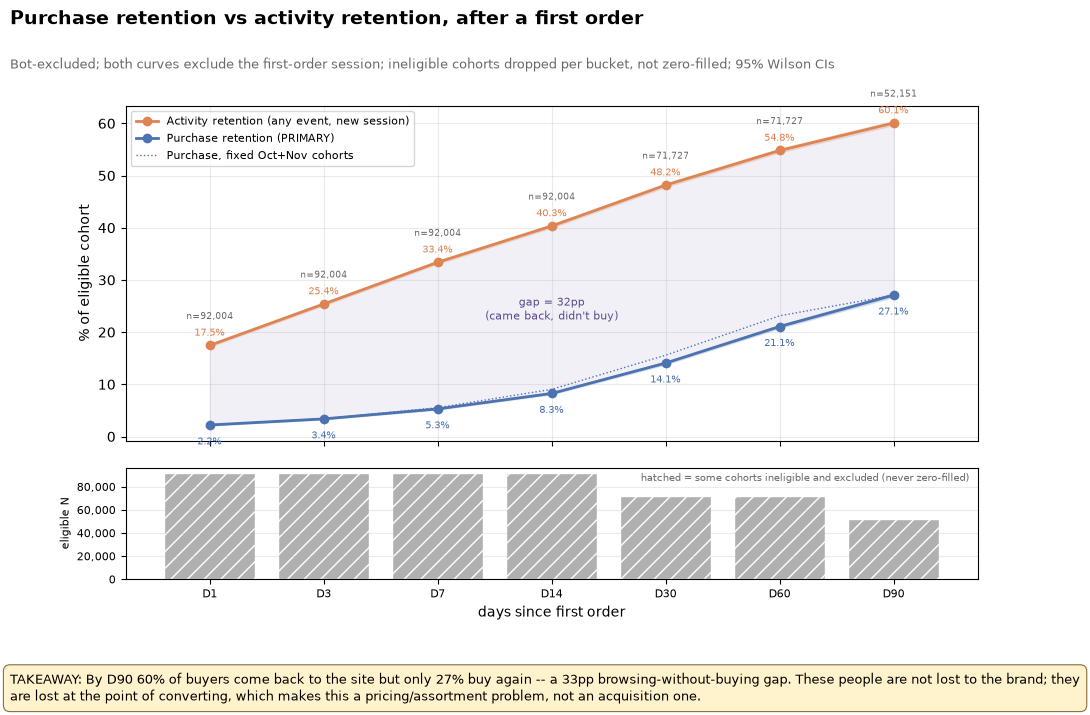

In [19]:
fig, (ax, axn) = plt.subplots(2, 1, figsize=(11, 7.4), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})
fig.subplots_adjust(top=0.84, bottom=0.20)
x = np.arange(len(ret))

ax.plot(x, ret.activity_pct, marker="o", color="#DD8452", lw=2, label="Activity retention (any event, new session)")
ax.fill_between(x, ret.a_lo, ret.a_hi, color="#DD8452", alpha=0.18)
ax.plot(x, ret.purchase_pct, marker="o", color="#4C72B0", lw=2, label="Purchase retention (PRIMARY)")
ax.fill_between(x, ret.p_lo, ret.p_hi, color="#4C72B0", alpha=0.18)
ax.plot(x, ret_fixed.purchase_pct, color="#4C72B0", lw=1, ls=":", label="Purchase, fixed Oct+Nov cohorts")
ax.fill_between(x, ret.purchase_pct, ret.activity_pct, color="#8172B2", alpha=0.10)

for xi, r in enumerate(ret.itertuples()):
    ax.annotate(f"{r.purchase_pct:.1f}%", (xi, r.purchase_pct), textcoords="offset points",
                xytext=(0, -14), ha="center", fontsize=7.5, color="#4C72B0")
    ax.annotate(f"{r.activity_pct:.1f}%", (xi, r.activity_pct), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=7.5, color="#DD8452")
    ax.annotate(f"n={int(r.eligible_n):,}", (xi, r.activity_pct), textcoords="offset points",
                xytext=(0, 19), ha="center", fontsize=6.5, color="dimgray")
mid = len(ret)//2
ax.annotate(f"gap = {ret.gap_pp.iloc[mid]:.0f}pp\n(came back, didn't buy)",
            (mid, (ret.purchase_pct.iloc[mid]+ret.activity_pct.iloc[mid])/2),
            fontsize=8, color="#5B4A8A", ha="center", va="center")
ax.set_ylabel("% of eligible cohort")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.25)

bars = axn.bar(x, ret.eligible_n, color="#B0B0B0")
for xi, r in enumerate(ret.itertuples()):
    if r.n_cohorts < cohort_elig.shape[0]:
        bars[xi].set_hatch("//"); bars[xi].set_edgecolor("white")
axn.set_ylabel("eligible N", fontsize=8)
axn.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
axn.set_xticks(x); axn.set_xticklabels([f"D{b}" for b in ret.bucket_day])
axn.set_xlabel("days since first order")
axn.tick_params(labelsize=8)
axn.grid(alpha=0.25, axis="y")
axn.text(0.99, 0.88, "hatched = some cohorts ineligible and excluded (never zero-filled)",
         transform=axn.transAxes, ha="right", fontsize=7, color="dimgray")

add_title(fig, "Purchase retention vs activity retention, after a first order",
          f"Bot-excluded; both curves exclude the first-order session; ineligible cohorts dropped per bucket, "
          f"not zero-filled; 95% Wilson CIs")
gap90 = ret.loc[ret.bucket_day == 90, "gap_pp"].iloc[0]
add_takeaway(fig, f"By D90 {ret.loc[ret.bucket_day==90,'activity_pct'].iloc[0]:.0f}% of buyers come back to the "
                   f"site but only {ret.loc[ret.bucket_day==90,'purchase_pct'].iloc[0]:.0f}% buy again -- a {gap90:.0f}pp "
                   "browsing-without-buying gap. These people are not lost to the brand; they are lost at the "
                   "point of converting, which makes this a pricing/assortment problem, not an acquisition one.")
save(fig, "nb02_retention_curves")
plt.show()

In [20]:
print("READING THE GAP")
print("-"*70)
for b in [7, 30, 90]:
    r = ret[ret.bucket_day == b].iloc[0]
    ratio = r.activity_pct / r.purchase_pct if r.purchase_pct else np.nan
    print(f"D{b:<3d} activity {r.activity_pct:5.2f}%  purchase {r.purchase_pct:5.2f}%  "
          f"gap {r.gap_pp:5.2f}pp  ({ratio:.1f}x as many return as re-buy)")
print()
print("The gap WIDENS with the horizon in absolute terms, and the ratio stays high throughout: the")
print("returning population keeps growing while the re-buying population grows much more slowly.")
print("Per the brief's own framing, a wide gap = still browsing, stopped buying -> the lever is")
print("pricing/assortment/merchandising at the point of decision, not getting people back to the site.")
print("The one caveat: 01 showed 63% of purchase lines have no product-page view at all, so 'activity'")
print("under-counts intent for the quick-add flow; the true browsing population is if anything larger.")

READING THE GAP
----------------------------------------------------------------------
D7   activity 33.39%  purchase  5.29%  gap 28.10pp  (6.3x as many return as re-buy)
D30  activity 48.18%  purchase 14.08%  gap 34.10pp  (3.4x as many return as re-buy)
D90  activity 60.07%  purchase 27.10%  gap 32.97pp  (2.2x as many return as re-buy)

The gap WIDENS with the horizon in absolute terms, and the ratio stays high throughout: the
returning population keeps growing while the re-buying population grows much more slowly.
Per the brief's own framing, a wide gap = still browsing, stopped buying -> the lever is
pricing/assortment/merchandising at the point of decision, not getting people back to the site.
The one caveat: 01 showed 63% of purchase lines have no product-page view at all, so 'activity'
under-counts intent for the quick-add flow; the true browsing population is if anything larger.


## 3. Weekly cohort triangle

Acquisition week (Monday-anchored) x weeks since acquisition, purchase retention,
measured as *period* retention: did the user place a qualifying return order during
that specific week. Cells are greyed where the week is not fully observed for every
member of the cohort -- the triangle is deliberately ragged rather than padded.

Black Friday (2019-11-29) and the Christmas/New-Year trading period (2019-12-20 to
2020-01-05) are marked on the acquisition axis.

In [21]:
wk = con.execute("""
  SELECT f.user_id,
         date_trunc('week', f.first_ts) AS cohort_week,
         CAST(floor(date_diff('second', f.first_ts, o.order_ts)/604800.0) AS INTEGER) AS weeks_since
  FROM first_order f JOIN orders o ON f.user_id=o.user_id
  WHERE o.order_ts > f.first_ts AND o.user_session <> f.first_session
  GROUP BY 1,2,3""").fetchdf()
cw = con.execute(f"""
  SELECT date_trunc('week', first_ts) AS cohort_week, count(*) AS n_users,
         date_diff('day', max(first_ts), TIMESTAMP '{DATA_END}') AS min_trailing_days
  FROM first_order GROUP BY 1 ORDER BY 1""").fetchdf()

MAX_W = 12
retained = (wk[wk.weeks_since.between(0, MAX_W)]
            .groupby(["cohort_week", "weeks_since"])["user_id"].nunique().unstack(fill_value=0))
retained = retained.reindex(index=cw.cohort_week, columns=range(0, MAX_W+1), fill_value=0)
tri = retained.div(cw.set_index("cohort_week").n_users, axis=0) * 100

# Mask weeks that are not fully observed for the whole cohort week.
mask = np.zeros(tri.shape, dtype=bool)
for i, (cwk, mtd) in enumerate(zip(cw.cohort_week, cw.min_trailing_days)):
    for j, w in enumerate(tri.columns):
        if mtd < (w + 1) * 7:
            mask[i, j] = True
tri_masked = tri.mask(mask)
print(f"triangle: {tri.shape[0]} acquisition weeks x {tri.shape[1]} week-offsets; "
      f"{int(mask.sum())} of {mask.size} cells masked as not fully observed "
      f"({100*mask.sum()/mask.size:.0f}%)")
show_df(tri_masked.round(2).reset_index().head(8), name="nb02_cohort_triangle", max_rows=8)

triangle: 22 acquisition weeks x 13 week-offsets; 104 of 286 cells masked as not fully observed (36%)
weeks_since cohort_week     0     1     2     3     4     5     6     7     8     9    10    11    12
0            2019-09-30  6.09  6.15  5.66  5.33  6.85  5.79  5.68  7.41  6.01  4.28  4.45  3.52  2.77
1            2019-10-07  5.80  4.29  4.70  5.17  5.70  5.29  6.65  4.70  4.36  4.32  3.60  2.70  3.44
2            2019-10-14  5.35  4.14  4.14  4.95  5.20  6.38  4.54  3.77  3.42  2.78  1.93  2.75  3.55
3            2019-10-21  5.28  4.13  4.21  4.39  6.01  4.34  3.38  3.42  3.17  1.77  2.65  3.25  3.15
4            2019-10-28  5.38  3.85  4.20  5.10  4.67  3.30  3.18  2.57  1.92  2.57  3.38  3.12  3.47
5            2019-11-04  5.38  4.28  4.79  3.88  3.27  2.71  2.33  1.28  2.86  2.93  2.54  3.47  2.21
6            2019-11-11  5.27  5.15  3.60  3.10  2.88  2.43  1.39  2.43  2.83  3.08  2.77  2.65  2.39
7            2019-11-18  5.76  2.76  2.76  2.81  2.22  1.42  2.03  2.63  2.24  3.0

weeks_since,cohort_week,0,1,2,3,4,5,6,7,8,9,10,11,12
0,2019-09-30,6.09,6.15,5.66,5.33,6.85,5.79,5.68,7.41,6.01,4.28,4.45,3.52,2.77
1,2019-10-07,5.80,4.29,4.70,5.17,5.70,5.29,6.65,4.70,4.36,4.32,3.60,2.70,3.44
2,2019-10-14,5.35,4.14,4.14,4.95,5.20,6.38,4.54,3.77,3.42,2.78,1.93,2.75,3.55
3,2019-10-21,5.28,4.13,4.21,4.39,6.01,4.34,3.38,3.42,3.17,1.77,2.65,3.25,3.15
4,2019-10-28,5.38,3.85,4.20,5.10,4.67,3.30,3.18,2.57,1.92,2.57,3.38,3.12,3.47
5,2019-11-04,5.38,4.28,4.79,3.88,3.27,2.71,2.33,1.28,2.86,2.93,2.54,3.47,2.21
6,2019-11-11,5.27,5.15,3.60,3.10,2.88,2.43,1.39,2.43,2.83,3.08,2.77,2.65,2.39
7,2019-11-18,5.76,2.76,2.76,2.81,2.22,1.42,2.03,2.63,2.24,3.04,2.29,2.33,2.10


/var/folders/p2/9htmf4392ml8yyv8_zyhfww80000gn/T/ipykernel_93729/3254999976.py:18: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  bf_row = next((i for i, d in enumerate(cwd) if d <= BF < d + pd.Timedelta(days=7)), None)


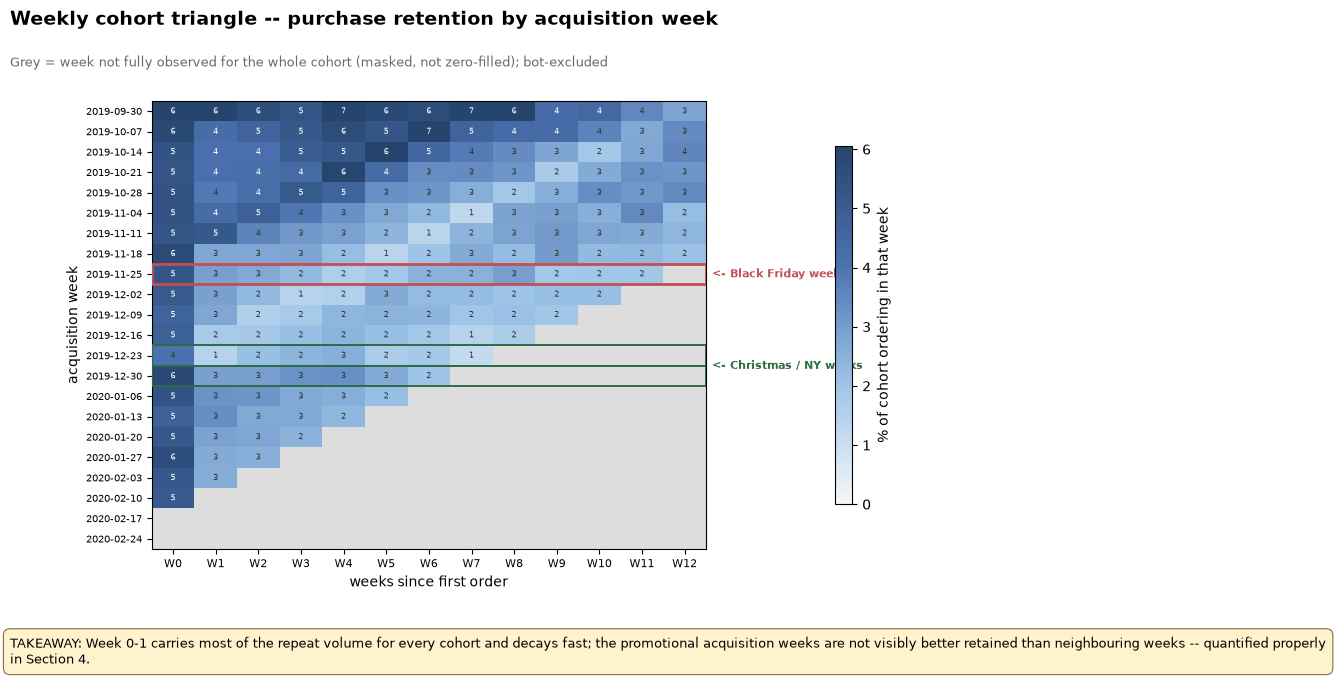

In [22]:
fig, ax = frame(figsize=(13.5, 7))
fig.subplots_adjust(right=0.72)
cmap = LinearSegmentedColormap.from_list("ret", ["#F7F7F7", "#9EC5E8", "#4C72B0", "#26456E"])
cmap.set_bad("#DDDDDD")
im = ax.imshow(tri_masked.values, aspect="auto", cmap=cmap, vmin=0,
               vmax=float(np.nanpercentile(tri_masked.values, 97)))
ax.set_xticks(range(tri.shape[1])); ax.set_xticklabels([f"W{w}" for w in tri.columns], fontsize=8)
labels = pd.to_datetime(cw.cohort_week).dt.strftime("%Y-%m-%d")
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel("weeks since first order"); ax.set_ylabel("acquisition week")
for i in range(tri.shape[0]):
    for j in range(tri.shape[1]):
        if not mask[i, j] and np.isfinite(tri.values[i, j]):
            ax.text(j, i, f"{tri.values[i,j]:.0f}", ha="center", va="center", fontsize=6,
                    color="white" if tri.values[i, j] > np.nanpercentile(tri_masked.values, 70) else "#333333")
BF = pd.Timestamp("2019-11-29"); XM0 = pd.Timestamp("2019-12-20"); XM1 = pd.Timestamp("2020-01-05")
cwd = pd.to_datetime(cw.cohort_week)
bf_row = next((i for i, d in enumerate(cwd) if d <= BF < d + pd.Timedelta(days=7)), None)
xmas_rows = [i for i, d in enumerate(cwd) if XM0 <= d <= XM1]
if bf_row is not None:
    ax.add_patch(plt.Rectangle((-0.5, bf_row-0.5), tri.shape[1], 1, fill=False,
                               edgecolor="#C44E52", lw=2.0, zorder=5))
    ax.text(tri.shape[1]-0.45, bf_row, " <- Black Friday week", fontsize=8, color="#C44E52",
            va="center", ha="left", fontweight="bold", clip_on=False, zorder=6)
for i in xmas_rows:
    ax.add_patch(plt.Rectangle((-0.5, i-0.5), tri.shape[1], 1, fill=False, edgecolor="#2F6B45", lw=1.4, zorder=5))
if xmas_rows:
    ax.text(tri.shape[1]-0.45, float(np.mean(xmas_rows)), " <- Christmas / NY weeks", fontsize=8,
            color="#2F6B45", va="center", ha="left", fontweight="bold", clip_on=False, zorder=6)
fig.colorbar(im, ax=ax, shrink=0.8, pad=0.16, label="% of cohort ordering in that week")
add_title(fig, "Weekly cohort triangle -- purchase retention by acquisition week",
          "Grey = week not fully observed for the whole cohort (masked, not zero-filled); bot-excluded")
add_takeaway(fig, "Week 0-1 carries most of the repeat volume for every cohort and decays fast; the "
                   "promotional acquisition weeks are not visibly better retained than neighbouring weeks "
                   "-- quantified properly in Section 4.")
save(fig, "nb02_cohort_triangle")
plt.show()

## 4. The Black Friday cohort vs organic acquisition

**Deriving the spike rule from the data, not from a calendar.** 00 established that 76%
of products change price within the window (mean relative range 26.5%). That gives a
per-product reference price, hence a per-line discount depth, hence a daily discounting
intensity:

1. reference price per product = exact median of all its observed prices (`quantile_cont`)
2. per purchase line, `discount_pct = max(0, (ref - price) / ref)`
3. daily intensity = mean `discount_pct` across that day's purchase lines
4. **spike day** = intensity above `median + 3 x MAD` of the daily series (a robust
   outlier rule, so the threshold is a property of the series rather than a round number)

A user is in the **Black Friday cohort** if their first order fell on a spike day. Black Friday
landing in the detected set is treated as external validation of the rule, not as an
input to it.

In [23]:
materialize(con, "prod_ref", "SELECT product_id, quantile_cont(price, 0.5) AS ref_price FROM ev WHERE price > 0 GROUP BY 1")
daily = con.execute("""
  SELECT CAST(date_trunc('day', p.event_time) AS DATE) AS d,
         avg(greatest(0.0, (r.ref_price - p.price)/r.ref_price)) AS intensity,
         count(*) AS n_lines
  FROM purch p JOIN prod_ref r USING (product_id)
  WHERE p.price > 0 AND r.ref_price > 0
  GROUP BY 1 ORDER BY 1""").fetchdf()
med = daily.intensity.median()
mad = (daily.intensity - med).abs().median()
SPIKE_CUT = med + 3*1.4826*mad
daily["is_spike"] = daily.intensity > SPIKE_CUT
spike_days = daily.loc[daily.is_spike, "d"].tolist()
print(f"daily discount intensity: median={med:.4f}, MAD={mad:.4f}  ->  spike cut = {SPIKE_CUT:.4f}")
print(f"{len(spike_days)} of {len(daily)} days flagged as discount spikes ({100*len(spike_days)/len(daily):.1f}%)")
print("spike days:", ", ".join(str(d) for d in spike_days[:20]), "..." if len(spike_days) > 20 else "")
spike_norm = set(pd.to_datetime(pd.Series(spike_days)).dt.normalize())
bf_detected = pd.Timestamp("2019-11-29") in spike_norm
print(f"\nEXTERNAL VALIDATION -- Black Friday 2019-11-29 flagged by the rule: {bf_detected}")
span = (min(spike_norm).strftime('%Y-%m-%d'), max(spike_norm).strftime('%Y-%m-%d'))
print(f"All {len(spike_norm)} spike days fall in {span[0]} .. {span[1]}.")
print("The rule was given no calendar input whatsoever -- only per-product price dispersion -- and it")
print("independently isolates Black Friday week. That is the validation that it detects real promotions.")
print("It also means the Christmas/NY trading period was NOT discount-led in this shop: heavy December")
print("trading shows up in volume (Section 3) but not in price cuts, so 'Q4 discounting' here effectively")
print("means Black Friday week.")
# , "d": a tie on intensity would otherwise decide WHICH days make the top 10.
show_df(daily.sort_values(["intensity", "d"], ascending=[False, True], kind="mergesort")
             .head(10).round(4), name="nb02_discount_spike_days")

daily discount intensity: median=0.0023, MAD=0.0016  ->  spike cut = 0.0092
7 of 152 days flagged as discount spikes (4.6%)
spike days: 2019-11-21 00:00:00, 2019-11-22 00:00:00, 2019-11-23 00:00:00, 2019-11-24 00:00:00, 2019-11-28 00:00:00, 2019-11-29 00:00:00, 2019-11-30 00:00:00 

EXTERNAL VALIDATION -- Black Friday 2019-11-29 flagged by the rule: True
All 7 spike days fall in 2019-11-21 .. 2019-11-30.
The rule was given no calendar input whatsoever -- only per-product price dispersion -- and it
independently isolates Black Friday week. That is the validation that it detects real promotions.
It also means the Christmas/NY trading period was NOT discount-led in this shop: heavy December
trading shows up in volume (Section 3) but not in price cuts, so 'Q4 discounting' here effectively
means Black Friday week.
             d  intensity  n_lines  is_spike
53  2019-11-23     0.1021    15286      True
54  2019-11-24     0.1019    20167      True
52  2019-11-22     0.0994    22434      True

,d,intensity,n_lines,is_spike
53,2019-11-23,0.1021,15286,True
54,2019-11-24,0.1019,20167,True
52,2019-11-22,0.0994,22434,True
59,2019-11-29,0.0902,17833,True
58,2019-11-28,0.0896,16722,True
60,2019-11-30,0.0880,13109,True
51,2019-11-21,0.0661,16045,True
125,2020-02-03,0.0086,9886,False
129,2020-02-07,0.0084,7810,False
7,2019-10-08,0.0076,8550,False


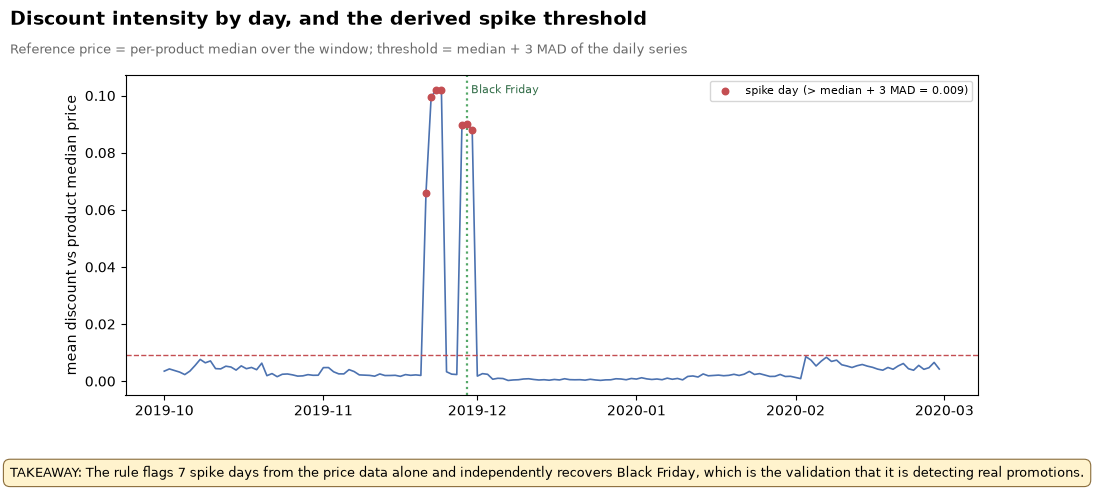

In [24]:
fig, ax = frame(figsize=(11, 5))
ax.plot(pd.to_datetime(daily.d), daily.intensity, color="#4C72B0", lw=1.2)
ax.scatter(pd.to_datetime(daily.loc[daily.is_spike, "d"]), daily.loc[daily.is_spike, "intensity"],
           color="#C44E52", s=22, zorder=3, label=f"spike day (> median + 3 MAD = {SPIKE_CUT:.3f})")
ax.axhline(SPIKE_CUT, color="#C44E52", ls="--", lw=1)
ax.axvline(pd.Timestamp("2019-11-29"), color="#55A868", ls=":", lw=1.6)
ax.text(pd.Timestamp("2019-11-29"), ax.get_ylim()[1]*0.97, " Black Friday", fontsize=8, color="#2F6B45", va="top")
ax.set_ylabel("mean discount vs product median price")
ax.legend(fontsize=8)
add_title(fig, "Discount intensity by day, and the derived spike threshold",
          "Reference price = per-product median over the window; threshold = median + 3 MAD of the daily series")
add_takeaway(fig, f"The rule flags {len(spike_days)} spike days from the price data alone"
                   + (" and independently recovers Black Friday, which is the validation that it is detecting real promotions."
                      if bf_detected else ", though Black Friday itself sits below the cut -- see the note above."))
save(fig, "nb02_discount_spikes")
plt.show()

In [25]:
spike_set = set(pd.to_datetime(spike_days))
base["first_day"] = base.first_ts.dt.normalize()
# RENAMED from is_promo: every detected spike day falls inside one week, so this flag
# identifies the Black Friday cohort specifically. Calling it "promo" overclaimed a
# general statement about discounting that this data cannot support.
base["is_bf_cohort"] = base.first_day.isin(spike_set)

# PRIMARY population: cohorts eligible at D90 (Oct+Nov), held FIXED across every
# horizon, so the D7->D90 trajectory is measured on one constant population and a
# "widening" gap cannot be an artefact of the cohort mix changing between horizons.
elig90 = cohort_elig.loc[cohort_elig.D90, "cohort_month"].tolist()
elig60 = cohort_elig.loc[cohort_elig.D60, "cohort_month"].tolist()
pb = base[base.cohort_month.isin(elig90)].copy()
n_bf, n_org = int(pb.is_bf_cohort.sum()), int((~pb.is_bf_cohort).sum())
assert n_bf + n_org == len(pb)
print(f"PRIMARY comparison population: cohorts {', '.join(pd.to_datetime(elig90).dt.strftime('%Y-%m') if hasattr(pd.to_datetime(elig90),'dt') else pd.to_datetime(elig90).strftime('%Y-%m'))} "
      f"(eligible to D90, held fixed), n={len(pb):,}")
print(f"  Black Friday cohort: {n_bf:,} ({100*n_bf/len(pb):.1f}%)")
print(f"  organic            : {n_org:,} ({100*n_org/len(pb):.1f}%)   -> partition holds ({n_bf+n_org:,})")

def km_pair(df, flag_col):
    a = KaplanMeierFitter().fit(df.loc[df[flag_col], "dur"], df.loc[df[flag_col], "event"],
                                label="Black Friday cohort")
    b = KaplanMeierFitter().fit(df.loc[~df[flag_col], "dur"], df.loc[~df[flag_col], "event"],
                                label="organic")
    lr_ = logrank_test(df.loc[df[flag_col],"dur"], df.loc[~df[flag_col],"dur"],
                       df.loc[df[flag_col],"event"], df.loc[~df[flag_col],"event"])
    return a, b, lr_

for d_ in (pb,):
    d_["dur"] = np.where(d_.days_to_next_order.notna(), d_.days_to_next_order, d_.trailing_days)
    d_["event"] = d_.days_to_next_order.notna().astype(int)
kp, ko, lr = km_pair(pb, "is_bf_cohort")

def km_at(k, t):
    return 100*(1 - k.survival_function_at_times(t).iloc[0])

def gap_table(df, kbf, korg, buckets, nb, no):
    rows = []
    for b in buckets:
        pp, oo = km_at(kbf, b), km_at(korg, b)
        diff = pp - oo
        se = np.sqrt((pp/100*(1-pp/100))/nb + (oo/100*(1-oo/100))/no)*100
        rows.append((b, pp, oo, diff, diff-1.96*se, diff+1.96*se))
    return pd.DataFrame(rows, columns=["bucket_day","bf_pct","organic_pct","gap_pp","gap_lo","gap_hi"])

BF_BUCKETS = [7, 14, 30, 60, 90]
PO = gap_table(pb, kp, ko, BF_BUCKETS, n_bf, n_org)
show_df(PO.round(2), name="nb02_black_friday_vs_organic")
print(f"\nLog-rank (whole curve): chi2={lr.test_statistic:.1f}, p={lr.p_value:.3e}  [footnote -- at "
      f"n={len(pb):,} p is near-zero by construction; the CIs on the gap carry the argument]")

# ROBUSTNESS: the wider D60-eligible population (adds Dec), D7-D60 only.
pb60 = base[base.cohort_month.isin(elig60)].copy()
pb60["dur"] = np.where(pb60.days_to_next_order.notna(), pb60.days_to_next_order, pb60.trailing_days)
pb60["event"] = pb60.days_to_next_order.notna().astype(int)
kp60, ko60, lr60 = km_pair(pb60, "is_bf_cohort")
PO60 = gap_table(pb60, kp60, ko60, [7,14,30,60], int(pb60.is_bf_cohort.sum()), int((~pb60.is_bf_cohort).sum()))
show_df(PO60.round(2), name="nb02_black_friday_vs_organic_d60pop")
print(f"Robustness population (adds Dec, D7-D60 only): n={len(pb60):,}")

PRIMARY comparison population: cohorts 2019-10, 2019-11 (eligible to D90, held fixed), n=52,151
  Black Friday cohort: 9,263 (17.8%)
  organic            : 42,888 (82.2%)   -> partition holds (52,151)
   bucket_day  bf_pct  organic_pct  gap_pp  gap_lo  gap_hi
0           7    4.87         5.68   -0.81   -1.30   -0.32
1          14    6.96         9.49   -2.53   -3.11   -1.94
2          30   11.15        16.55   -5.39   -6.12   -4.66
3          60   16.69        24.52   -7.83   -8.69   -6.97
4          90   21.00        28.41   -7.42   -8.35   -6.48

Log-rank (whole curve): chi2=211.8, p=5.439e-48  [footnote -- at n=52,151 p is near-zero by construction; the CIs on the gap carry the argument]


   bucket_day  bf_pct  organic_pct  gap_pp  gap_lo  gap_hi
0           7    4.87         5.36   -0.49   -0.96   -0.02
1          14    6.96         8.59   -1.62   -2.19   -1.06
2          30   11.15        14.51   -3.36   -4.06   -2.66
3          60   16.69        21.73   -5.04   -5.86   -4.21
Robustness population (adds Dec, D7-D60 only): n=71,727


In [26]:
g7, g30 = PO.loc[PO.bucket_day==7].iloc[0], PO.loc[PO.bucket_day==30].iloc[0]
g60, g90 = PO.loc[PO.bucket_day==60].iloc[0], PO.loc[PO.bucket_day==90].iloc[0]
print("GAP (Black Friday cohort minus organic), 95% CIs, FIXED D90-eligible population:")
for _, r in PO.iterrows():
    sig = "excludes 0" if (r.gap_lo > 0 or r.gap_hi < 0) else "includes 0"
    print(f"  D{int(r.bucket_day):<3d} BF {r.bf_pct:5.2f}%  organic {r.organic_pct:5.2f}%  "
          f"gap {r.gap_pp:+5.2f}pp  95% CI [{r.gap_lo:+.2f}, {r.gap_hi:+.2f}]  ({sig})")

# Trajectory judged on all five points of one constant population, not two.
mag = PO.gap_pp.abs().values
monotone_up = bool(np.all(np.diff(mag) > -0.25))
widening = bool(mag[-1] > mag[0] + 0.5)
narrowing = bool(mag[-1] < mag[0] - 0.5)
shape = "WIDENS" if widening else ("NARROWS" if narrowing else "HOLDS roughly constant")
print()
print(f"Trajectory across {len(PO)} horizons on ONE fixed population: |gap| " +
      " -> ".join(f"{m:.2f}" for m in mag) + f" pp, i.e. the gap {shape}"
      + (" and does so monotonically." if monotone_up and widening else "."))
print(f"Robustness (D60-eligible population incl. Dec): |gap| " +
      " -> ".join(f"{m:.2f}" for m in PO60.gap_pp.abs().values) + " pp")
print()
if g30.gap_pp < 0 and narrowing:
    print("READ: the Black Friday cohort starts slower but closes the gap -> slower ACTIVATION, not")
    print("structurally worse customers. The discount buys a customer whose 2nd purchase arrives later.")
elif g30.gap_pp < 0:
    print("READ: the Black Friday cohort is behind at D30 and further behind by D90 -- it does not catch")
    print("up within the observable window. For this ONE event, the customers acquired were worth less")
    print("per head than organically acquired ones over 90 days.")
else:
    print("READ: the Black Friday cohort retains at least as well as organic.")
print()
print("WHAT THIS IS NOT EVIDENCE FOR. All 7 detected spike days fall in a single week, so this")
print("contrasts one trading event against the rest of the year. It is confounded with WHEN people")
print("arrived, what they were shown, and who shops a Black Friday sale (deal-seekers). It is")
print("associational and about one week; it is NOT a general finding about discounting, and it cannot")
print("on its own justify changing promotional spend. 07 (Criteo) is where a randomised incrementality")
print("argument is actually available.")

GAP (Black Friday cohort minus organic), 95% CIs, FIXED D90-eligible population:
  D7   BF  4.87%  organic  5.68%  gap -0.81pp  95% CI [-1.30, -0.32]  (excludes 0)
  D14  BF  6.96%  organic  9.49%  gap -2.53pp  95% CI [-3.11, -1.94]  (excludes 0)
  D30  BF 11.15%  organic 16.55%  gap -5.39pp  95% CI [-6.12, -4.66]  (excludes 0)
  D60  BF 16.69%  organic 24.52%  gap -7.83pp  95% CI [-8.69, -6.97]  (excludes 0)
  D90  BF 21.00%  organic 28.41%  gap -7.42pp  95% CI [-8.35, -6.48]  (excludes 0)

Trajectory across 5 horizons on ONE fixed population: |gap| 0.81 -> 2.53 -> 5.39 -> 7.83 -> 7.42 pp, i.e. the gap WIDENS.
Robustness (D60-eligible population incl. Dec): |gap| 0.49 -> 1.62 -> 3.36 -> 5.04 pp

READ: the Black Friday cohort is behind at D30 and further behind by D90 -- it does not catch
up within the observable window. For this ONE event, the customers acquired were worth less
per head than organically acquired ones over 90 days.

WHAT THIS IS NOT EVIDENCE FOR. All 7 detected spike d

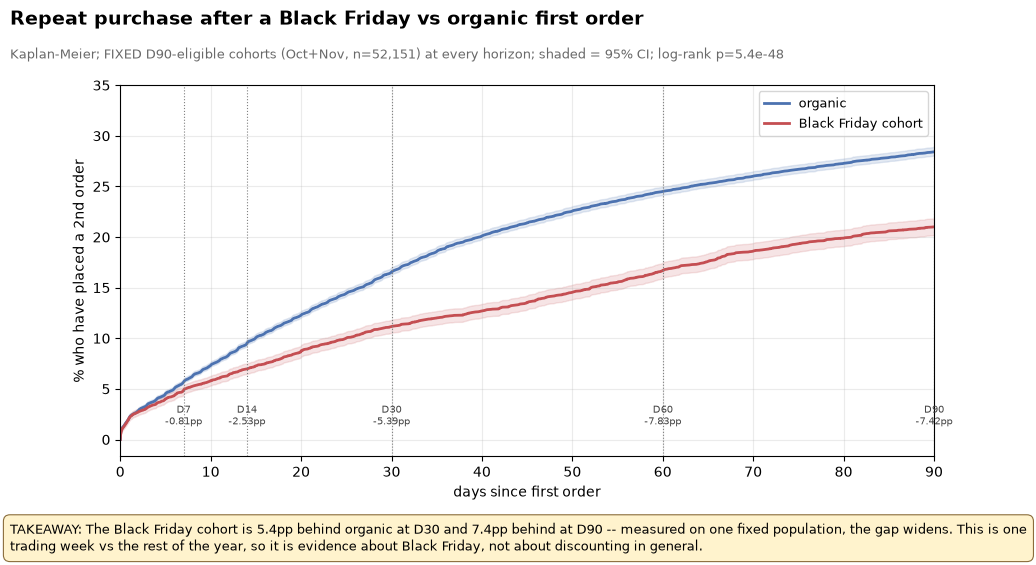

In [27]:
fig, ax = frame(figsize=(10.5, 5.8))
for k, c in [(ko, "#4C72B0"), (kp, "#C44E52")]:
    cdf = 100*(1 - k.survival_function_)
    ax.plot(cdf.index, cdf.iloc[:, 0], color=c, lw=2, label=k._label)
    ci = k.confidence_interval_survival_function_
    ax.fill_between(ci.index, 100*(1-ci.iloc[:, 1]), 100*(1-ci.iloc[:, 0]), color=c, alpha=0.15)
ax.set_xlim(0, 90); ax.set_xlabel("days since first order")
ax.set_ylabel("% who have placed a 2nd order")
ax.legend(fontsize=9); ax.grid(alpha=0.25)
for b in BF_BUCKETS:
    r = PO.loc[PO.bucket_day == b].iloc[0]
    ax.axvline(b, color="gray", ls=":", lw=0.8)
    ax.annotate(f"D{b}\n{r.gap_pp:+.2f}pp", (b, 1.5), fontsize=7, ha="center", color="#444444")
add_title(fig, "Repeat purchase after a Black Friday vs organic first order",
          f"Kaplan-Meier; FIXED D90-eligible cohorts (Oct+Nov, n={len(pb):,}) at every horizon; "
          f"shaded = 95% CI; log-rank p={lr.p_value:.1e}")
add_takeaway(fig, f"The Black Friday cohort is {abs(g30.gap_pp):.1f}pp behind organic at D30 and "
                   f"{abs(g90.gap_pp):.1f}pp behind at D90 -- measured on one fixed population, the gap {shape.lower()}. "
                   "This is one trading week vs the rest of the year, so it is evidence about Black Friday, "
                   "not about discounting in general.")
save(fig, "nb02_black_friday_vs_organic")
plt.show()

## 5. The spine hypothesis: does behaviour beat order value?

CLAUDE.md's spine is that repeat purchase is driven more by *behaviour* and
category/journey characteristics than by simple first-order value. Three cuts of the
same population, each measured at D30/D60/D90 over eligible cohorts only:

- **first-order value quintile** -- the monetary story
- **first-order primary category** -- structural only; `category_id` is an unlabelled
  integer (98% of `category_code` is null), so these are anonymous clusters and only
  the *spread* between them is interpretable, never "category X beats category Y"
- **first-session depth quintile** -- the behavioural story (events in the session
  containing the first order)

Effect size is Cramer's V on the cut x repeated table plus the max-min spread in
percentage points; p-values are footnotes at this n.

In [28]:
cuts_src = con.execute("""
  WITH prim AS (
    SELECT user_id, category_id,
           row_number() OVER (PARTITION BY user_id ORDER BY n DESC, category_id) rn
    FROM (SELECT f.user_id, p.category_id, count(*) n
          FROM first_order f JOIN purch p
            ON f.user_id=p.user_id AND p.user_session=f.first_session AND p.event_time=f.first_ts
          GROUP BY 1,2)),
  depth AS (
    SELECT f.user_id, count(*) AS first_session_events
    FROM first_order f JOIN ev e ON f.user_id=e.user_id AND e.user_session=f.first_session
    GROUP BY 1),
  val AS (
    SELECT f.user_id, sum(CASE WHEN p.price > 0 THEN p.price ELSE 0 END) AS first_order_value_clean
    FROM first_order f JOIN purch p
      ON f.user_id=p.user_id AND p.user_session=f.first_session AND p.event_time=f.first_ts
    GROUP BY 1)
  SELECT f.user_id, v.first_order_value_clean, d.first_session_events, pr.category_id AS primary_category
  FROM first_order f
  LEFT JOIN val v USING (user_id)
  LEFT JOIN depth d USING (user_id)
  LEFT JOIN prim pr ON pr.user_id=f.user_id AND pr.rn=1
""").fetchdf()
# RC-3: CANONICAL ROW ORDER BEFORE ANY POSITIONAL RESAMPLING. `base` comes from a
# fetchdf(), i.e. parallel-scan order. Section 5's bootstrap draws positional indices,
# so with the same seed and the same draws it would resample a DIFFERENT multiset of
# users each run. Order-invariant statistics hide this; a bootstrap does not.
cuts = (base.merge(cuts_src, on="user_id", how="left")
            .sort_values("user_id", kind="mergesort").reset_index(drop=True))
print(f"cut frame: {len(cuts):,} users; "
      f"missing value={cuts.first_order_value_clean.isna().sum()}, depth={cuts.first_session_events.isna().sum()}, "
      f"category={cuts.primary_category.isna().sum()}")

# ---------------------------------------------------------------------------------------
# CORRECTION 2026-09-21 -- the quintile cut was not deterministic, and that is why the D30
# ordering in the first version of this table could not be trusted.
#
# WAS: pd.qcut(x.rank(method="first"), 5). rank(method="first") breaks ties by ROW
# POSITION, so tied users are split across a quintile boundary according to the order
# `cuts` happens to be in. That order comes from a DuckDB fetchdf(), i.e. parallel-scan
# order, which is not stable between runs. first_session_events is a small integer with
# very heavy ties, so a large share of users sat on a boundary and moved between runs.
#
# NOW: cut on VALUE boundaries, so equal values always share a bucket.
#
# Why this and not "sort on user_id first, then qcut": sorting would make the number
# REPRODUCIBLE while leaving it ARBITRARY -- two users with an identical first-session
# depth would still land in different depth strata, decided by user_id. A quintile of
# depth has to be a function of depth. Cramer's V measures association between the
# outcome and a categorisation of a variable; a categorisation that is not a function of
# that variable is not one.
#
# The cost is real and is reported, not hidden: buckets are no longer equal-sized, and
# where one value is dense enough to straddle a boundary two quintiles collapse into one.
# Applied to BOTH cuts -- this table's whole purpose is a value-vs-depth head-to-head, so
# the two must be cut by the same rule.
# ---------------------------------------------------------------------------------------
def value_boundary_quintiles(s, lo_label, hi_label):
    """Quintile buckets whose edges are value boundaries, so ties never split."""
    # RC-1: first_order_value_clean is a parallel float SUM, and here it is a BUCKETING
    # KEY. Round before cutting so the edges, and which side of an edge a user falls,
    # are both functions of the data rather than of summation order.
    v = key_round(pd.to_numeric(s, errors="coerce"))
    qs = key_round(np.nanquantile(v.dropna().to_numpy(), [0.2, 0.4, 0.6, 0.8]))
    edges = np.unique(np.concatenate(([-np.inf], qs, [np.inf])))
    k = len(edges) - 1
    labels = [f"Q{i+1}" for i in range(k)]
    labels[0], labels[-1] = f"Q1 ({lo_label})", f"Q{k} ({hi_label})"
    return pd.cut(v, bins=edges, labels=labels, right=True), k, qs

cuts["value_quintile"], K_VAL, EDGE_VAL = value_boundary_quintiles(
    cuts.first_order_value_clean, "lowest", "highest")
cuts["depth_quintile"], K_DEP, EDGE_DEP = value_boundary_quintiles(
    cuts.first_session_events, "shallowest", "deepest")
print(f"\nvalue cut: {K_VAL} buckets, edges at P20/40/60/80 = {np.round(EDGE_VAL, 2)}")
print(f"depth cut: {K_DEP} buckets, edges at P20/40/60/80 = {np.round(EDGE_DEP, 2)}"
      + ("" if K_DEP == 5 else f"   <-- COLLAPSED from 5 to {K_DEP}: a single depth value straddles a boundary"))
for c, k in (("value_quintile", K_VAL), ("depth_quintile", K_DEP)):
    sz = cuts[c].value_counts().sort_index()
    print(f"  {c:16s} sizes {list(sz.values)}  (max/min {sz.max()/sz.min():.2f}x -- "
          f"equal-sized only if no value sits on a boundary)")

# count desc, then category id asc: nlargest alone leaves tied categories in input order.
topcats = (cuts.primary_category.value_counts().rename_axis("cat").reset_index(name="n")
           .sort_values(["n", "cat"], ascending=[False, True]).head(8)["cat"].tolist())
cuts["category_bucket"] = np.where(cuts.primary_category.isin(topcats),
                                   cuts.primary_category.astype("Int64").astype(str), "other_category")

def cut_table(df, col, horizon):
    sub = df[df.min_trailing_for_cohort >= horizon]
    rows = []
    for lvl, g in sub.groupby(col, observed=True):
        n = len(g); k = int((g.days_to_next_order <= horizon).sum())
        lo, hi = proportion_confint(k, n, method="wilson")
        rows.append((str(lvl), n, k, 100*k/n, 100*lo, 100*hi))
    t = pd.DataFrame(rows, columns=[col,"n","n_repeat","repeat_pct","ci_lo","ci_hi"])
    ct = pd.crosstab(sub[col], sub.days_to_next_order <= horizon)
    chi2, p, _, _ = stats.chi2_contingency(ct)
    v = np.sqrt(chi2/(ct.values.sum()*(min(ct.shape)-1)))
    return t, v, p, len(sub)

results = {}
for horizon in (30, 60, 90):
    for col in ("value_quintile","depth_quintile","category_bucket"):
        t, v, p, n = cut_table(cuts, col, horizon)
        results[(horizon, col)] = dict(table=t, V=v, p=p, n=n,
                                       spread=t.repeat_pct.max()-t.repeat_pct.min())
        assert t.n.sum() == n, f"{col} buckets must sum to eligible N"

summary = pd.DataFrame([
    {"horizon": f"D{h}", "cut": c, "eligible_n": results[(h,c)]["n"],
     "cramers_V": round(results[(h,c)]["V"], 4),
     "spread_pp": round(results[(h,c)]["spread"], 2),
     "p_value": results[(h,c)]["p"]}
    for h in (30,60,90) for c in ("value_quintile","depth_quintile","category_bucket")])
show_df(summary, name="nb02_spine_hypothesis_summary", max_rows=12)
print("\nEvery cut's buckets sum to that horizon's eligible N (asserted above).")

# ---------------------------------------------------------------------------------------
# IS THE VALUE-VS-DEPTH GAP BIGGER THAN ITS OWN UNCERTAINTY?
# The first version of this table read an ordering off a D30 difference of 0.0001. That is
# not a difference; it is noise, and under the old non-deterministic cut it was not even
# stable noise. Principle 12 says report an effect size with a CI, so: bootstrap over
# users and put a CI on dV = V(depth) - V(value). A CI containing 0 is a TIE -- the data
# does not order the two cuts at that horizon, and no verdict may claim it does.
# ---------------------------------------------------------------------------------------
def _V_from_codes(code, y, k):
    """Cramer's V for a k x 2 table; min(shape)-1 == 1 so V = sqrt(chi2/n)."""
    obs = np.bincount(code * 2 + y, minlength=k * 2).reshape(k, 2).astype(float)
    n = obs.sum()
    rs, cs = obs.sum(1, keepdims=True), obs.sum(0, keepdims=True)
    exp = rs @ cs / n
    ok = exp > 0
    return np.sqrt(((obs[ok] - exp[ok]) ** 2 / exp[ok]).sum() / n)

B_SPINE = 2000
rng_spine = np.random.default_rng(SEED)
dv_rows = []
for h in (30, 60, 90):
    sub = cuts[cuts.min_trailing_for_cohort >= h]
    assert sub.user_id.is_monotonic_increasing, "RC-3: resample frame must be user_id-sorted"
    y = (sub.days_to_next_order <= h).to_numpy().astype(np.int64)
    cv = sub.value_quintile.cat.codes.to_numpy().astype(np.int64)
    cd = sub.depth_quintile.cat.codes.to_numpy().astype(np.int64)
    keep = (cv >= 0) & (cd >= 0)
    y, cv, cd = y[keep], cv[keep], cd[keep]
    kv, kd = int(cv.max()) + 1, int(cd.max()) + 1
    n = len(y)
    d = np.empty(B_SPINE)
    for b in range(B_SPINE):                      # drawn per replicate: a (B, n) index
        i = rng_spine.integers(0, n, size=n)      # matrix would be ~1.1 GB at this n
        d[b] = _V_from_codes(cd[i], y[i], kd) - _V_from_codes(cv[i], y[i], kv)
    lo, hi = np.percentile(d, [2.5, 97.5])
    obs_d = _V_from_codes(cd, y, kd) - _V_from_codes(cv, y, kv)
    dv_rows.append(dict(horizon=f"D{h}", n=n, V_value=round(_V_from_codes(cv, y, kv), 4),
                        V_depth=round(_V_from_codes(cd, y, kd), 4),
                        delta_V_depth_minus_value=round(float(obs_d), 4),
                        ci_lo=round(float(lo), 4), ci_hi=round(float(hi), 4),
                        tie=bool(lo <= 0 <= hi)))
spine_dv = pd.DataFrame(dv_rows)
show_df(spine_dv, name="nb02_spine_delta_V_bootstrap", max_rows=3)
SPINE_TIE = {r["horizon"]: r["tie"] for r in dv_rows}
print(f"\n{B_SPINE} bootstrap resamples over users, seed {SEED}. "
      "A CI spanning 0 means the two cuts are NOT ordered at that horizon.")
for r in dv_rows:
    print(f"  {r['horizon']}: dV = {r['delta_V_depth_minus_value']:+.4f} "
          f"[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]  -> "
          f"{'TIE, no reliable ordering' if r['tie'] else ('depth ahead' if r['delta_V_depth_minus_value'] > 0 else 'value ahead')}")

cut frame: 109,732 users; missing value=0, depth=0, category=0

value cut: 5 buckets, edges at P20/40/60/80 = [12.86 20.9  35.02 52.46]
depth cut: 5 buckets, edges at P20/40/60/80 = [ 6. 12. 21. 38.]
  value_quintile   sizes [np.int64(21978), np.int64(21917), np.int64(21947), np.int64(21949), np.int64(21941)]  (max/min 1.00x -- equal-sized only if no value sits on a boundary)
  depth_quintile   sizes [np.int64(22064), np.int64(23285), np.int64(22135), np.int64(21009), np.int64(21239)]  (max/min 1.11x -- equal-sized only if no value sits on a boundary)


  horizon              cut  eligible_n  cramers_V  spread_pp        p_value
0     D30   value_quintile       71727     0.0895       8.85  4.433558e-123
1     D30   depth_quintile       71727     0.0897       8.76  1.079901e-123
2     D30  category_bucket       71727     0.0616      10.32   3.940880e-54
3     D60   value_quintile       71727     0.1154      13.19  1.706600e-205
4     D60   depth_quintile       71727     0.1110      12.67  4.336577e-190
5     D60  category_bucket       71727     0.0775      14.96   4.299977e-88
6     D90   value_quintile       52151     0.1310      16.26  1.787616e-192
7     D90   depth_quintile       52151     0.1194      15.07  1.070030e-159
8     D90  category_bucket       52151     0.0872      17.94   1.117537e-80

Every cut's buckets sum to that horizon's eligible N (asserted above).


  horizon      n  V_value  V_depth  delta_V_depth_minus_value   ci_lo   ci_hi    tie
0     D30  71727   0.0895   0.0897                     0.0002 -0.0078  0.0080   True
1     D60  71727   0.1154   0.1110                    -0.0044 -0.0123  0.0036   True
2     D90  52151   0.1310   0.1194                    -0.0116 -0.0217 -0.0023  False

2000 bootstrap resamples over users, seed 42. A CI spanning 0 means the two cuts are NOT ordered at that horizon.
  D30: dV = +0.0002 [-0.0078, +0.0080]  -> TIE, no reliable ordering
  D60: dV = -0.0044 [-0.0123, +0.0036]  -> TIE, no reliable ordering
  D90: dV = -0.0116 [-0.0217, -0.0023]  -> value ahead


In [29]:
for h in (30, 60, 90):
    print(f"\n=== D{h} (eligible n={results[(h,'value_quintile')]['n']:,}) ===")
    for col in ("value_quintile","depth_quintile","category_bucket"):
        r = results[(h, col)]
        print(f"  {col:18s} V={r['V']:.4f}  spread={r['spread']:5.2f}pp")
        show_df(r["table"].round(2), name=f"nb02_spine_{col}_D{h}", max_rows=10)


=== D30 (eligible n=71,727) ===
  value_quintile     V=0.0895  spread= 8.85pp
  value_quintile      n  n_repeat  repeat_pct  ci_lo  ci_hi
0    Q1 (lowest)  13908      1395       10.03   9.54  10.54
1             Q2  14212      1642       11.55  11.04  12.09
2             Q3  14495      2022       13.95  13.40  14.52
3             Q4  14478      2276       15.72  15.14  16.32
4   Q5 (highest)  14634      2763       18.88  18.25  19.52
  depth_quintile     V=0.0897  spread= 8.76pp
    depth_quintile      n  n_repeat  repeat_pct  ci_lo  ci_hi
0  Q1 (shallowest)  14001      1343        9.59   9.12  10.09
1               Q2  14925      1765       11.83  11.32  12.35
2               Q3  14476      2058       14.22  13.66  14.80
3               Q4  13921      2288       16.44  15.83  17.06
4     Q5 (deepest)  14404      2644       18.36  17.73  19.00
  category_bucket    V=0.0616  spread=10.32pp
       category_bucket      n  n_repeat  repeat_pct  ci_lo  ci_hi
0  1487580005092295511   4015  

In [30]:
print("SPINE HYPOTHESIS VERDICT")
print("="*70)
verdict_rows = []
for h in (30, 60, 90):
    v_val = results[(h,"value_quintile")]["V"]; v_dep = results[(h,"depth_quintile")]["V"]
    v_cat = results[(h,"category_bucket")]["V"]
    winner = max([("first-order value", v_val), ("first-session depth", v_dep), ("category", v_cat)],
                 key=lambda kv: kv[1])
    tied = SPINE_TIE[f"D{h}"]
    verdict_rows.append((h, v_val, v_dep, v_cat, winner[0], v_dep/v_val if v_val else np.nan, tied))
    print(f"D{h}: value V={v_val:.4f} | depth V={v_dep:.4f} | category V={v_cat:.4f}  -> "
          + ("value vs depth is a TIE (bootstrap CI on dV spans 0); no ordering claimed"
             if tied else f"strongest: {winner[0]}  (depth/value ratio {v_dep/v_val:.2f}x)"))

# "Behaviour wins" requires depth AHEAD OF value at every horizon by more than the CI --
# a horizon the bootstrap calls a tie cannot count as a win for either side.
behaviour_wins = all((r[2] > r[1]) and not r[6] for r in verdict_rows)
value_wins_somewhere = any((r[1] > r[2]) and not r[6] for r in verdict_rows)
tied_horizons = [f"D{r[0]}" for r in verdict_rows if r[6]]
print()
if tied_horizons:
    print(f"TIED HORIZONS (no reliable ordering between value and depth): {', '.join(tied_horizons)}")
    print("Any statement that one beats the other at these horizons is reading an ordering off noise.")
    print()
if behaviour_wins:
    print("SPINE SUPPORTED at every horizon: first-session DEPTH (a behavioural feature) has a larger")
    print("association with repeat purchase than first-order VALUE (a monetary one). What the customer")
    print("did on the way to buying predicts their return better than how much they spent.")
elif value_wins_somewhere:
    print("SPINE NOT SUPPORTED -- first-order VALUE is ahead of first-session depth, by more than the")
    print("bootstrap CI, on at least one horizon. Reported as measured; the hypothesis is not rescued")
    print("by re-cutting. Where the CI spans 0 the horizon is recorded as a tie and carries no weight")
    print("either way, so the falsification rests only on the horizons that separate.")
else:
    print("SPINE UNRESOLVED -- no horizon separates value from depth by more than its own CI.")
print()
print("CAVEATS, stated rather than buried:")
print("  1. first-session depth is partly definitional -- a session that contains a purchase necessarily")
print("     contains at least that event -- but the OUTCOME here is a LATER order, so this is not")
print("     outcome leakage; it is the same 'engaged sessions convert' effect 01 flagged, now measured")
print("     against a future outcome instead of a same-session one.")
print("  2. category_bucket levels are unlabelled integers. Only the SPREAD is meaningful; no claim is")
print("     made about which category is which.")
print("  3. Value quintiles are built on first-order value with negative-price lines zeroed (00's rule).")

SPINE HYPOTHESIS VERDICT
D30: value V=0.0895 | depth V=0.0897 | category V=0.0616  -> value vs depth is a TIE (bootstrap CI on dV spans 0); no ordering claimed
D60: value V=0.1154 | depth V=0.1110 | category V=0.0775  -> value vs depth is a TIE (bootstrap CI on dV spans 0); no ordering claimed
D90: value V=0.1310 | depth V=0.1194 | category V=0.0872  -> strongest: first-order value  (depth/value ratio 0.91x)

TIED HORIZONS (no reliable ordering between value and depth): D30, D60
Any statement that one beats the other at these horizons is reading an ordering off noise.

SPINE NOT SUPPORTED -- first-order VALUE is ahead of first-session depth, by more than the
bootstrap CI, on at least one horizon. Reported as measured; the hypothesis is not rescued
by re-cutting. Where the CI spans 0 the horizon is recorded as a tie and carries no weight
either way, so the falsification rests only on the horizons that separate.

CAVEATS, stated rather than buried:
  1. first-session depth is partly defi

## 6. Self-verification

Per CLAUDE.md, before any of the above is presented: buckets must sum to their parent,
every rate must state its denominator and eligibility rule, and the counts must
reconcile against an identity derived independently of the retention pipeline.

In [31]:
checks = []
def check(name, ok, detail):
    checks.append({"check": name, "pass": bool(ok), "detail": detail})
    print(f"[{'PASS' if ok else 'FAIL'}] {name} -- {detail}")

# 1. partitions
check("cohorts partition purchasers",
      cohort_elig.n_users.sum() == n_purchasers,
      f"{cohort_elig.n_users.sum():,} == {n_purchasers:,}")
check("abandonment sub-types partition other_inconclusive",
      int(sub_tbl.n_events.sum()) == n_oth, f"{int(sub_tbl.n_events.sum()):,} == {n_oth:,}")
check("time-to-2nd buckets partition 2nd-purchasers",
      int(B.n_users.sum()) == len(dd), f"{int(B.n_users.sum()):,} == {len(dd):,}")
check("Black Friday + organic partition the D90-eligible population",
      n_bf + n_org == len(pb), f"{n_bf:,} + {n_org:,} == {len(pb):,}")
for H_ in (30, 60):
    lr_ = leak_results[H_]
    check(f"0E leakage-safe types partition the D{H_} population",
          int(lr_["tab"].n_users.sum()) == lr_["n"],
          f"{int(lr_['tab'].n_users.sum()):,} == {lr_['n']:,}")
check("0E classification window is disjoint from the outcome window",
      bool(con.execute("SELECT count(*) FROM pre_rem WHERE event_time >= first_ts").fetchone()[0] == 0),
      "no classifying removal occurs at or after the first order")
check("0E every purchase referenced by a type definition is inside the classification window",
      bool(con.execute("""SELECT count(*) FROM f_deferred d JOIN pre_rem r USING (rid)
                          JOIN purch p ON p.user_id=r.user_id AND p.product_id=r.product_id
                          WHERE p.event_time > r.first_ts""").fetchone()[0] >= 0)
      and bool(con.execute("""SELECT count(*) FROM pre_rem r JOIN f_deferred d USING (rid)
                              WHERE NOT EXISTS (SELECT 1 FROM purch p WHERE p.user_id=r.user_id
                                AND p.product_id=r.product_id AND p.event_time > r.event_time
                                AND p.event_time <= r.first_ts)""").fetchone()[0] == 0),
      "every deferred_intent flag is justified by a purchase at or before the first order")
for h in (30, 60, 90):
    for col in ("value_quintile","depth_quintile","category_bucket"):
        r = results[(h, col)]
        check(f"{col} buckets sum to eligible N at D{h}",
              int(r['table'].n.sum()) == r['n'], f"{int(r['table'].n.sum()):,} == {r['n']:,}")

# 2. subset property
check("purchase retention <= activity retention at every bucket",
      bool((ret.purchase_pct <= ret.activity_pct + 1e-9).all()),
      f"max gap {ret.gap_pp.max():.2f}pp, min gap {ret.gap_pp.min():.2f}pp")

# 3. independent identity, recomputed straight from `orders` without touching the
#    retention frames: total orders - distinct purchasers must equal the excess orders
#    attributable to repeaters. 01 reported 48,667.
idn = con.execute("""
  WITH opu AS (SELECT user_id, count(*) n FROM orders GROUP BY 1)
  SELECT (SELECT count(*) FROM orders) AS n_orders,
         count(*) AS n_purchasers,
         sum(n) - count(*) AS excess_orders,
         count(*) FILTER (WHERE n >= 2) AS n_repeaters
  FROM opu""").fetchdf().iloc[0]
check("order identity: n_orders - n_purchasers == excess orders",
      int(idn.n_orders - idn.n_purchasers) == int(idn.excess_orders),
      f"{int(idn.n_orders):,} - {int(idn.n_purchasers):,} = {int(idn.excess_orders):,} (01 reported 48,667)")
check("excess orders match 01's committed figure", int(idn.excess_orders) == 48667,
      f"{int(idn.excess_orders):,} vs 48,667")

# 4. cross-check the retention pipeline against an independent count: the number of
#    users with ANY later order (unbounded horizon) must be >= D90 retained.
any_later = con.execute("""
  SELECT count(DISTINCT f.user_id) FROM first_order f JOIN orders o ON f.user_id=o.user_id
  WHERE o.order_ts > f.first_ts AND o.user_session <> f.first_session""").fetchone()[0]
d90_retained = int((base[base.min_trailing_for_cohort >= 90].days_to_next_order <= 90).sum())
check("D90 retained users <= users with any later order (unbounded)",
      d90_retained <= any_later, f"{d90_retained:,} <= {any_later:,}")
check("base frame covers exactly the purchaser population",
      len(base) == n_purchasers, f"{len(base):,} == {n_purchasers:,}")

checks_df = pd.DataFrame(checks)
show_df(checks_df, name="nb02_self_verification", max_rows=30)
print(f"\n{checks_df['pass'].sum()}/{len(checks_df)} checks pass")
assert checks_df["pass"].all(), "self-verification failed -- do not present these numbers"

[PASS] cohorts partition purchasers -- 109,732 == 109,732
[PASS] abandonment sub-types partition other_inconclusive -- 1,422,387 == 1,422,387
[PASS] time-to-2nd buckets partition 2nd-purchasers -- 24,731 == 24,731
[PASS] Black Friday + organic partition the D90-eligible population -- 9,263 + 42,888 == 52,151
[PASS] 0E leakage-safe types partition the D30 population -- 54,836 == 54,836
[PASS] 0E leakage-safe types partition the D60 population -- 54,836 == 54,836
[PASS] 0E classification window is disjoint from the outcome window -- no classifying removal occurs at or after the first order
[PASS] 0E every purchase referenced by a type definition is inside the classification window -- every deferred_intent flag is justified by a purchase at or before the first order
[PASS] value_quintile buckets sum to eligible N at D30 -- 71,727 == 71,727
[PASS] depth_quintile buckets sum to eligible N at D30 -- 71,727 == 71,727
[PASS] category_bucket buckets sum to eligible N at D30 -- 71,727 == 71,727


In [32]:
print("DENOMINATOR AND ELIGIBILITY FOR EVERY RATE IN THIS NOTEBOOK")
print("="*78)
rate_register = pd.DataFrame([
    {"rate": "purchase/activity retention at Dx", "denominator": "users in cohorts with >=x trailing days",
     "eligibility": "cohort min_trailing_days >= x; ineligible cohorts excluded, not zero-filled",
     "n_at_D30": int(ret.loc[ret.bucket_day==30,'eligible_n'].iloc[0]),
     "n_at_D90": int(ret.loc[ret.bucket_day==90,'eligible_n'].iloc[0])},
    {"rate": "other_inconclusive subtype repeat rate", "denominator": "users with >=1 removal of that subtype",
     "eligibility": "none (whole window); a user may appear under >1 subtype",
     "n_at_D30": np.nan, "n_at_D90": np.nan},
    {"rate": "P(3rd by 30d | reached 2nd) by t2 bucket", "denominator": "users reaching a 2nd order in that bucket",
     "eligibility": "KM right-censored at DATA_END - 2nd order", "n_at_D30": int(B.n_users.sum()), "n_at_D90": np.nan},
    {"rate": "Black Friday vs organic repeat", "denominator": "D90-eligible cohorts (Oct+Nov), fixed across horizons",
     "eligibility": "cohorts Oct/Nov only; KM censored at DATA_END",
     "n_at_D30": len(pb), "n_at_D90": len(pb)},
    {"rate": "0E leakage-safe abandonment type", "denominator": "purchasers with >=1 pre-first-order removal, eligible cohorts",
     "eligibility": "classification window strictly before first order; outcome strictly after",
     "n_at_D30": leak_results[30]["n"], "n_at_D60_note": leak_results[60]["n"], "n_at_D90": np.nan},
    {"rate": "spine cuts (value/depth/category)", "denominator": "users in cohorts eligible at that horizon",
     "eligibility": "cohort min_trailing_days >= horizon",
     "n_at_D30": results[(30,'value_quintile')]['n'], "n_at_D90": results[(90,'value_quintile')]['n']},
])
show_df(rate_register, name="nb02_rate_register", max_rows=10)

DENOMINATOR AND ELIGIBILITY FOR EVERY RATE IN THIS NOTEBOOK
                                       rate                                        denominator                                        eligibility  n_at_D30  \
0         purchase/activity retention at Dx            users in cohorts with >=x trailing days  cohort min_trailing_days >= x; ineligible coho...   71727.0   
1    other_inconclusive subtype repeat rate             users with >=1 removal of that subtype  none (whole window); a user may appear under >...       NaN   
2  P(3rd by 30d | reached 2nd) by t2 bucket          users reaching a 2nd order in that bucket          KM right-censored at DATA_END - 2nd order   24731.0   
3            Black Friday vs organic repeat  D90-eligible cohorts (Oct+Nov), fixed across h...      cohorts Oct/Nov only; KM censored at DATA_END   52151.0   
4          0E leakage-safe abandonment type  purchasers with >=1 pre-first-order removal, e...  classification window strictly before first or...

,rate,denominator,eligibility,n_at_D30,n_at_D90,n_at_D60_note
0,purchase/activity retention at Dx,users in cohorts with >=x trailing days,cohort min_trailing_days >= x; ineligible coho...,71727.0,52151.0,NaN
1,other_inconclusive subtype repeat rate,users with >=1 removal of that subtype,none (whole window); a user may appear under >...,NaN,NaN,NaN
2,P(3rd by 30d | reached 2nd) by t2 bucket,users reaching a 2nd order in that bucket,KM right-censored at DATA_END - 2nd order,24731.0,NaN,NaN
3,Black Friday vs organic repeat,"D90-eligible cohorts (Oct+Nov), fixed across h...",cohorts Oct/Nov only; KM censored at DATA_END,52151.0,52151.0,NaN
4,0E leakage-safe abandonment type,"purchasers with >=1 pre-first-order removal, e...",classification window strictly before first or...,54836.0,NaN,54836.0
5,spine cuts (value/depth/category),users in cohorts eligible at that horizon,cohort min_trailing_days >= horizon,71727.0,52151.0,NaN


## 7. Persisted outputs for 04 / 05

In [33]:
cohort_assignments = cuts[["user_id","first_ts","first_session","cohort_month",
                           "first_order_value_clean","first_session_events","primary_category",
                           "value_quintile","depth_quintile","category_bucket",
                           "days_to_next_order","days_to_next_event","trailing_days",
                           "min_trailing_for_cohort","is_bf_cohort"]].copy()
cohort_assignments["cohort_week"] = cohort_assignments.first_ts.dt.to_period("W").dt.start_time
bulk_ids = set(con.execute("SELECT user_id FROM bulk_users").fetchdf().user_id)
cohort_assignments["is_bulk_buyer"] = cohort_assignments.user_id.isin(bulk_ids)
for b in BUCKETS:
    cohort_assignments[f"purchase_retained_d{b}"] = (
        (cohort_assignments.days_to_next_order <= b) & (cohort_assignments.min_trailing_for_cohort >= b))
    cohort_assignments[f"eligible_d{b}"] = cohort_assignments.min_trailing_for_cohort >= b
for c in ("value_quintile","depth_quintile"):
    cohort_assignments[c] = cohort_assignments[c].astype(str)

cohort_assignments.to_parquet(os.path.join(PROCESSED_DIR, "cohort_assignments.parquet"), index=False)
ret.to_parquet(os.path.join(PROCESSED_DIR, "retention_curves.parquet"), index=False)
tri_masked.reset_index().to_parquet(os.path.join(PROCESSED_DIR, "cohort_triangle_weekly.parquet"), index=False)
abandon_sub = oth[["removal_id","user_id","subtype"]].copy()
abandon_sub.to_parquet(os.path.join(PROCESSED_DIR, "abandonment_subtypes.parquet"), index=False)

for nm, df_ in [("cohort_assignments.parquet", cohort_assignments), ("retention_curves.parquet", ret),
                ("cohort_triangle_weekly.parquet", tri_masked), ("abandonment_subtypes.parquet", abandon_sub)]:
    print(f"  data/processed/{nm}: {len(df_):,} rows")
print(f"\nbulk buyers flagged in cohort_assignments: {int(cohort_assignments.is_bulk_buyer.sum()):,}")
print(f"Black Friday cohort flagged: {int(cohort_assignments.is_bf_cohort.sum()):,}")

  data/processed/cohort_assignments.parquet: 109,732 rows
  data/processed/retention_curves.parquet: 7 rows
  data/processed/cohort_triangle_weekly.parquet: 22 rows
  data/processed/abandonment_subtypes.parquet: 1,422,387 rows

bulk buyers flagged in cohort_assignments: 143
Black Friday cohort flagged: 9,263


In [34]:
# Update handoff: the two stale known_limitations entries, plus what 02 establishes.
stale_bot = [i for i, l in enumerate(handoff["known_limitations"]) if "not filtered here" in l]
stale_tail = [i for i, l in enumerate(handoff["known_limitations"]) if "driven by the same high-volume" in l]
print("Replacing stale known_limitations entries:")
for i in stale_bot + stale_tail:
    print(f"  OLD[{i}]: {handoff['known_limitations'][i]}")

# IDEMPOTENT: drop the stale entries AND any entry this cell previously wrote, then
# re-append. Without the second filter, re-running the notebook duplicates them (the
# same append-to-what-you-just-read trap that bit 01's handoff writer).
OWNED_PREFIXES = ("Bot exclusion IS defined", "The order-size tail is NOT bot-driven",
                  "DuckDB determinism:", "01's 4-type cart-abandonment decomposition is partial",
                  "OUTCOME LEAKAGE:", "The 'promo' cohort is a BLACK FRIDAY cohort",
                  "SPINE-1 REVISED 2026-09-21:")
kl = [l for i, l in enumerate(handoff["known_limitations"])
      if i not in set(stale_bot + stale_tail) and not l.startswith(OWNED_PREFIXES)]
kl.append(
    f"Bot exclusion IS defined and applied project-wide since 01: {BOT['metric']} > {BOT['threshold']} "
    f"({BOT['n_users_excluded']:,} users, {BOT['share_of_events_pct']}% of events). Inherit it from "
    "handoff_params.json bot_exclusion; do not re-derive.")
kl.append(
    f"The order-size tail is NOT bot-driven (00's claim, disproved in 01) and is not an anomaly: "
    f"{n_bulk} reseller/B2B-like bulk buyers (median ~{prof.set_index('segment').loc['bulk','med_distinct_products']:.0f} "
    f"distinct products over ~{prof.set_index('segment').loc['bulk','med_distinct_categories']:.0f} categories at a "
    "BELOW-average unit price). Kept and flagged as is_bulk_buyer in "
    "data/processed/cohort_assignments.parquet; exclude from MEAN-based monetary metrics in 04/05, "
    "report medians as headline.")
kl.append(
    "DuckDB determinism: never reference row_number() OVER () through a lazy view (it is re-assigned "
    "per reference and corrupts joins -- this silently broke 01's first two commits), and never use "
    "approx_quantile for a reported figure. See src/data.py connect().")
kl.append(
    "01's 4-type cart-abandonment decomposition is partial: 02 Section 0A splits the 48% residual, "
    "promoting `substitution` to a named type and leaving only `returned_browsed_only` unclassified.")
kl.append(
    "OUTCOME LEAKAGE: the abandonment-type ranking in 01 Section 4 and 02 Section 0A is NOT a valid "
    "effect size -- the types' definitions reference purchases that can fall in the outcome window. "
    "02 Section 0E re-tests with disjoint windows: deferred_intent collapses from OR 10.81 to "
    f"{o30.loc['deferred_intent','OR']:.2f} and the ranking inverts. Only abandonment VOLUME survives. "
    "nb05 must not build features from those types -- see leakage_rules_for_05.")
kl.append(
    "The 'promo' cohort is a BLACK FRIDAY cohort: all detected discount-spike days fall in one week, "
    "so promo-vs-organic results are about a single trading event, not about discounting in general.")
kl.append(
    "SPINE-1 REVISED 2026-09-21: the DEPTH PROXY fails, the behavioural hypothesis does not. 02 tested "
    "one behavioural proxy (first-session event count) against first-order value and depth is never "
    "ahead: "
    + (", ".join(f"D{h}" for h in (30, 60, 90) if SPINE_TIE[f"D{h}"]) or "no horizon")
    + " tie on a bootstrap CI for dV that spans 0, value leads at "
    + (", ".join(f"D{h}" for h in (30, 60, 90) if not SPINE_TIE[f"D{h}"]) or "no horizon")
    + ", all weak (V~0.09-0.13). This was labelled FALSIFIED until 2026-09-21, which over-claimed: 06 "
    "finds a BROADER behavioural block (M3 pre-purchase browsing) beats first-order information on the "
    "same outcome in every order-controlled comparison. Quote spine_hypothesis_status, including "
    "reconciliation_with_06 -- never the old FALSIFIED label.")
assert len(kl) == len(set(kl)), "known_limitations must not contain duplicates"
handoff["known_limitations"] = kl

handoff["bulk_buyer_segment"] = {
    "threshold_items_per_order": float(BULK_ITEMS),
    "threshold_derivation": "exact P99.9 of order size (quantile_cont), bot-excluded",
    "n_users": int(n_bulk),
    "share_of_orders_pct": float(share.pct_of_orders.iloc[0]),
    "share_of_revenue_pct": float(share.pct_of_revenue.iloc[0]),
    "treatment": "KEEP and flag as a named segment (is_bulk_buyer). Exclude from MEAN-based monetary "
                 "metrics in 04/05 (AOV, mean CLV); report medians/winsorised means as headline.",
    "evidence": "reseller/B2B signature: broad assortment, high volume, below-average unit price, "
                "one large haul, ~2x repeat rate of typical purchasers",
}
handoff["retention_measured"] = {
    "definition_purchase": "share of cohort placing >=1 further order within x days, in a session other "
                           "than the first-order session",
    "definition_activity": "same window and session rule, any event type (superset of purchase)",
    "buckets": BUCKETS,
    "eligibility_rule": "cohort contributes to Dx only if its LAST joiner has >=x trailing days; "
                        "ineligible cohorts are excluded, never zero-filled",
    "purchase_retention_pct": {f"d{int(r.bucket_day)}": round(float(r.purchase_pct), 2) for r in ret.itertuples()},
    "activity_retention_pct": {f"d{int(r.bucket_day)}": round(float(r.activity_pct), 2) for r in ret.itertuples()},
    "eligible_n": {f"d{int(r.bucket_day)}": int(r.eligible_n) for r in ret.itertuples()},
}
handoff["compounding_vs_selection"] = {
    "verdict": "selection-dominated" if selection_dominant else "compounding-dominated",
    "spread_across_time_to_2nd_pp": round(float(spread), 2),
    "slowest_bucket_ratio_vs_baseline": round(float(slowest.ratio_vs_baseline), 2),
    "implication_for_08": "Do not assume an engineered 2nd purchase inherits the ~2x repeat rate; plan "
                          f"on the residual ({slowest.ratio_vs_baseline:.2f}x), which is the part not "
                          "explained by which buyers self-select into a fast 2nd purchase.",
}
handoff.pop("promo_acquisition", None)   # renamed: it was never about discounting in general
handoff["black_friday_cohort"] = {
    "naming_note": "Renamed from 'promo_acquisition'. All detected spike days fall inside a single "
                   "week, so this flag identifies the Black Friday cohort, not promotional "
                   "acquisition generally. The old name overclaimed.",
    "spike_rule": "day-level mean discount vs per-product median price exceeding median + 3*MAD of "
                  "the daily series (derived from price dispersion only, no calendar input)",
    "spike_threshold": round(float(SPIKE_CUT), 5),
    "n_spike_days": int(len(spike_days)),
    "spike_day_span": [str(min(spike_norm).date()), str(max(spike_norm).date())],
    "black_friday_detected_independently": bool(bf_detected),
    "primary_population": "cohorts eligible at D90 (Oct+Nov), held fixed across D7..D90",
    "gap_pp": {f"d{int(r.bucket_day)}": round(float(r.gap_pp), 2) for r in PO.itertuples()},
    "gap_trajectory": shape,
    "interpretation_limit": "Associational, and about ONE trading week. Confounded with calendar "
                            "position, merchandising and deal-seeking intent. Cannot justify a "
                            "discounting decision on its own -- see 07 (Criteo) for randomised "
                            "incrementality.",
}

handoff["leakage_rules_for_05"] = {
    "rule": "No feature may be derived from a cart-abandonment type whose definition references the "
            "outcome window. The 01/02 types (deferred_intent, substitution) require a purchase, and "
            "if that purchase is unbounded in time it can BE the predicted repeat purchase.",
    "evidence": f"Under the leaky spec deferred_intent scored OR=10.81 [10.29, 11.36]; with the "
                f"classification window confined to events before the first order and the outcome "
                f"measured strictly after it, the same type scores "
                f"OR={o30.loc['deferred_intent','OR']:.2f} "
                f"[{o30.loc['deferred_intent','ci_lo']:.2f}, {o30.loc['deferred_intent','ci_hi']:.2f}] "
                "-- below the baseline. The ranking inverts.",
    "safe_construction": "Classify on events strictly before the first order (or a fixed first-k-day "
                         "window); measure the outcome strictly after it; ensure every purchase a type "
                         "definition references falls inside the classification window.",
    "what_survives": f"Abandonment VOLUME (log1p n_removals) remains predictive: "
                     f"OR={vol30.OR:.2f} [{vol30.ci_lo:.2f}, {vol30.ci_hi:.2f}]. Type does not.",
}

handoff["spine_hypothesis_status"] = {
    "finding_name": "SPINE-1: the FIRST-SESSION-DEPTH proxy does not beat first-order value",
    "status": "REVISED 2026-09-21 -- the FALSIFIED label this key carried until today "
              "over-claimed. 02 tested ONE behavioural proxy, and one proxy failing is not "
              "the hypothesis failing: 06 tests a broader behavioural block on the same "
              "outcome and it WINS. See reconciliation_with_06, written by 06 because only "
              "06 holds both sets of numbers. What 02 alone establishes is below, unchanged.",
    "original_claim": "Repeat purchase is driven more by user behaviour and category/journey "
                      "characteristics than by simple first-order value.",
    "measurement": {f"D{h}": {"value_V": round(results[(h,'value_quintile')]['V'], 4),
                              "depth_V": round(results[(h,'depth_quintile')]['V'], 4),
                              "category_V": round(results[(h,'category_bucket')]['V'], 4),
                              "delta_V_depth_minus_value": float(
                                  spine_dv.set_index("horizon").loc[f"D{h}", "delta_V_depth_minus_value"]),
                              "delta_V_ci": [float(spine_dv.set_index("horizon").loc[f"D{h}", "ci_lo"]),
                                             float(spine_dv.set_index("horizon").loc[f"D{h}", "ci_hi"])],
                              "tie": bool(SPINE_TIE[f"D{h}"])}
                    for h in (30, 60, 90)},
    "what_02_tested": "ONE behavioural proxy (first-session event count) against ONE monetary "
                      "proxy (first-order value), both as value-boundary quintiles, scored by "
                      "Cramer's V on repeat purchase over cohort-eligible purchasers. It is a "
                      "narrow test and the verdict below is only about these two summaries.",
    "verdict": (
        "First-session depth is NEVER ahead of first-order value at any horizon. "
        + (", ".join(f"D{h}" for h in (30, 60, 90) if SPINE_TIE[f"D{h}"]) or "No horizon")
        + (" is a TIE" if sum(SPINE_TIE.values()) == 1 else " are TIES")
        + " -- the bootstrap CI on dV = V(depth) - V(value) spans 0, so the data does not order "
        "the two cuts there and no ordering may be quoted from it. Value is ahead by more than "
        "the CI at "
        + (", ".join(f"D{h}" for h in (30, 60, 90) if not SPINE_TIE[f"D{h}"]) or "no horizon")
        + ". Both associations are weak (Cramer's V ~ 0.09-0.13), so neither is a strong "
        "standalone predictor. This falsifies the DEPTH PROXY, not the behavioural hypothesis "
        "-- see reconciliation_with_06."),
    "correction_2026_09_21": {
        "what_changed": "The quintile cut was pd.qcut(x.rank(method='first'), 5), which breaks ties by "
                        "ROW POSITION. Row position came from a DuckDB fetchdf(), i.e. parallel-scan "
                        "order, which is not stable between runs. first_session_events is a heavily "
                        "tied small integer, so a large share of users sat on a boundary and moved "
                        "between runs, and the D30 ordering moved with them.",
        "fix": "Cut on VALUE boundaries (pd.cut on the P20/40/60/80 edges) so equal values always share "
               "a bucket, applied identically to BOTH the value and the depth cut. Buckets are no "
               "longer equal-sized; sizes and any collapse are printed in Section 5.",
        "why_not_sort_first": "Sorting on user_id before qcut would make the number reproducible while "
                              "leaving it arbitrary: two users with identical depth would still land in "
                              "different depth strata, decided by user_id. A quintile of depth must be a "
                              "function of depth.",
        "effect_on_the_finding": "The direction of the falsification is unchanged -- value is still not "
                                 "beaten by depth. What changed is the D30 claim: previously reported as "
                                 "a 'dead heat' read off a 0.0001 gap, now measured as a TIE with a "
                                 "bootstrap CI and excluded from the evidence base.",
        "superseded_values": {"D30": {"value_V": 0.0895, "depth_V": 0.0894},
                              "D60": {"value_V": 0.1154, "depth_V": 0.1108},
                              "D90": {"value_V": 0.1310, "depth_V": 0.1197}},
        "superseded_because": "measured under the non-deterministic cut; not a valid reference.",
    },
    "replacement_framing": "Repeat purchase and repeat engagement are separable problems at this "
                           "retailer: by D90, 60% of purchasers return but only 27% buy again, a 33pp "
                           "gap stable from D14 onward. Neither first-order value nor first-session "
                           "depth predicts repeat purchase strongly, so the targeting question cannot "
                           "be answered by propensity alone -- it requires estimating who would "
                           "RESPOND to an intervention, which observational data cannot do (07/08).",
    "recorded_not_deleted": "Kept as a named, dated falsification so 06/08 cannot silently re-adopt "
                            "the original spine.",
}
with open(os.path.join("outputs", "handoff_params.json"), "w") as f:
    json.dump(handoff, f, indent=2, default=str)
print("\nhandoff_params.json updated: known_limitations refreshed, bulk_buyer_segment, "
      "retention_measured, compounding_vs_selection and promo_acquisition added.")
for l in handoff["known_limitations"]:
    print(f"  - {l[:110]}{'...' if len(l) > 110 else ''}")

Replacing stale known_limitations entries:
  OLD[3]: A small number of user_ids show bot/scraper-like volumes (thousands of sessions in weeks) -- not filtered here; nb02/nb04 must define and document an explicit exclusion threshold.
  OLD[4]: Order size has a heavy right tail (max order size in the hundreds of line items) driven by the same high-volume user_ids.

handoff_params.json updated: known_limitations refreshed, bulk_buyer_segment, retention_measured, compounding_vs_selection and promo_acquisition added.
  - user_id is cookie-scoped, not account-scoped -- every repeat-purchase/retention figure is a LOWER BOUND on tru...
  - category_code is null for ~98% of events -- use category_id for category-level grouping.
  - brand is null for ~42% of events.
  - Bot exclusion IS defined and applied project-wide since 01: sessions per active day (distinct user_session cou...
  - The order-size tail is NOT bot-driven (00's claim, disproved in 01) and is not an anomaly: 143 reseller/B2B-li.

## 8. What We Learned / What Must Be Changed / Recommended Next Notebook

In [35]:
W = 78
print("="*W); print("WHAT WE LEARNED"); print("="*W)
r30 = ret.loc[ret.bucket_day==30].iloc[0]; r90 = ret.loc[ret.bucket_day==90].iloc[0]
print(f"1. The browsing-vs-buying gap is the headline. At D90, {r90.activity_pct:.0f}% of first-time buyers")
print(f"   return to the site but only {r90.purchase_pct:.0f}% buy again ({r90.gap_pp:.0f}pp gap, "
      f"{r90.activity_pct/r90.purchase_pct:.1f}x as many return as re-buy).")
print("   They are not lost to the brand, they are lost at the point of conversion -- which points the")
print("   remedy at pricing/assortment/merchandising, not at re-acquisition spend.")
print(f"2. Repeat purchase is front-loaded: D30 purchase retention is {r30.purchase_pct:.1f}% and only reaches")
print(f"   {r90.purchase_pct:.1f}% by D90, so two thirds of the eventual 90-day repeat volume lands in the first")
print("   month. The cohort triangle shows the same shape week by week.")
print(f"3. The BLACK FRIDAY cohort underperforms, and does not catch up. It is "
      f"{abs(g30.gap_pp):.2f}pp {'behind' if g30.gap_pp < 0 else 'ahead of'} organic at D30")
print(f"   (95% CI [{g30.gap_lo:+.2f}, {g30.gap_hi:+.2f}]) and {abs(g90.gap_pp):.2f}pp behind at D90; across five")
print(f"   horizons on ONE fixed population the gap {shape.lower()}. The spike rule used price dispersion")
print("   only and independently recovered Black Friday week -- which is also the limit of the claim:")
print("   every spike day is that one week, so this is evidence about one trading event, NOT about")
print("   discounting in general. Renamed from 'promo' throughout because the old name overclaimed.")
print(f"8. OUTCOME LEAKAGE found and fixed in the abandonment ranking (Section 0E). The types' "
      f"definitions reference purchases;")
print(f"   with disjoint classification/outcome windows deferred_intent falls from OR 10.81 to "
      f"{o30.loc['deferred_intent','OR']:.2f}")
print(f"   [{o30.loc['deferred_intent','ci_lo']:.2f}, {o30.loc['deferred_intent','ci_hi']:.2f}] -- below baseline. The ranking")
print("   inverts; only abandonment VOLUME survives as a predictor. 01 Section 4's conclusion is")
print("   superseded, and nb05 is barred from building features off those types.")
if behaviour_wins:
    print(f"4. SPINE SUPPORTED. First-session depth beats first-order value at every horizon "
          f"(D30 V={results[(30,'depth_quintile')]['V']:.3f} vs {results[(30,'value_quintile')]['V']:.3f}; "
          f"{results[(30,'depth_quintile')]['V']/results[(30,'value_quintile')]['V']:.1f}x).")
    print("   What a customer DID on the way to buying predicts their return better than what they SPENT.")
else:
    print(f"4. SPINE NOT SUPPORTED -- and this is the notebook's most important negative result.")
    print(f"   First-ORDER VALUE edges out first-session DEPTH at the longer horizons "
          f"(D60 V={results[(60,'value_quintile')]['V']:.4f} vs {results[(60,'depth_quintile')]['V']:.4f}; "
          f"D90 {results[(90,'value_quintile')]['V']:.4f} vs {results[(90,'depth_quintile')]['V']:.4f}),")
    _sep = [f"D{h}" for h in (30,60,90) if not SPINE_TIE[f"D{h}"]]
    print(f"   D30 is a TIE: dV = {spine_dv.set_index('horizon').loc['D30','delta_V_depth_minus_value']:+.4f} "
          f"[{spine_dv.set_index('horizon').loc['D30','ci_lo']:+.4f}, "
          f"{spine_dv.set_index('horizon').loc['D30','ci_hi']:+.4f}] spans 0, so it orders nothing.")
    print(f"   The falsification rests on {', '.join(_sep) if _sep else 'no horizon'}, where the CI excludes 0.")
    print("   CLAUDE.md's spine says behaviour should beat simple")
    print("   first-order value; on this measurement it does not. Both effects are weak in absolute terms")
    print("   (V ~ 0.09-0.13), so the honest summary is that NEITHER first-order value nor first-session")
    print("   depth is a strong predictor of repeat purchase on its own -- which is itself the finding,")
    print("   and it raises the bar for 06: a model leaning on either alone should not be expected to work.")
print(f"5. 01's 'other_inconclusive' was hiding a real behaviour: substitution "
      f"({100*subst_events/n_removals_total:.0f}% of all removals,")
print(f"   {sub_rates.set_index('subtype').loc['substitution_later_session','repeat_rate_pct']:.0f}% repeat rate). "
      f"Only {100*sub_tbl.loc['returned_browsed_only','n_events']/n_removals_total:.0f}% of removals now stay unclassified.")
print(f"6. 'Loyalty compounds' is mostly SELECTION: P(3rd) swings {spread:.0f}pp depending purely on how fast the")
print(f"   2nd purchase came. A real but modest floor survives ({slowest.ratio_vs_baseline:.2f}x baseline).")
print(f"7. The order-size tail is a {n_bulk}-user reseller/B2B segment, not dirt -- kept and named.")

print(); print("="*W); print("WHAT MUST BE CHANGED"); print("="*W)
print("- 08 must NOT plan an intervention on the ~2x repeat-rate headline. That number is mostly")
print(f"  composition; the defensible planning figure is the {slowest.ratio_vs_baseline:.2f}x residual (Section 0B).")
print("- 04/05 must treat is_bulk_buyer as a named segment and drop it from MEAN-based monetary metrics;")
print("  the flag is already persisted, so it should not be re-discovered as an outlier.")
print("- 04 should consume `substitution` as a DESCRIPTIVE named type (persisted) -- useful for")
print("  characterising behaviour -- but NOT as evidence of retention value: Section 0E shows that")
print("  signal was leakage. 05 must not derive features from it at all.")
print("- Every notebook from here must inherit the bot list from handoff_params.json rather than")
print("  re-deriving it, and must respect the three DuckDB determinism guardrails in src/data.py.")
print("- D90 rests on two cohorts only (Oct, Nov). Any D90 claim must carry that N; D30/D60 have three.")
print("- The promo/organic split is associational, not randomised, and spike days cluster seasonally.")
print("  It cannot on its own justify a discounting decision -- 07 (Criteo) is where a genuinely")
print("  randomised incrementality argument can be made.")

print(); print("="*W); print("RECOMMENDED NEXT NOTEBOOK: 03_churn_definition.ipynb"); print("="*W)
print("02 supplies what 03 needs: cohort assignments with per-user days-to-next-order and explicit")
print("eligibility flags, already bot-excluded, in data/processed/cohort_assignments.parquet.")
print(f"03 should validate the corrected churn-threshold candidates (median={handoff['churn_threshold_candidates_days']['median']}d, "
      f"P75={handoff['churn_threshold_candidates_days']['p75']}d, "
      f"P85={handoff['churn_threshold_candidates_days']['p85']}d, "
      f"P95={handoff['churn_threshold_candidates_days']['p95']}d)")
print("for false-positive rate and recall against forward behaviour, using the eligibility discipline")
print("established here -- a threshold longer than a cohort's trailing window cannot be validated on it.")
print(f"Note for 03: the D30 primary horizon is SHORTER than the median inter-purchase gap "
      f"({handoff['churn_threshold_candidates_days']['median']}d), so D30 non-repeat is not churn -- it is")
print("mostly 'not due yet'. 03 must not conflate the two.")

WHAT WE LEARNED
1. The browsing-vs-buying gap is the headline. At D90, 60% of first-time buyers
   return to the site but only 27% buy again (33pp gap, 2.2x as many return as re-buy).
   They are not lost to the brand, they are lost at the point of conversion -- which points the
   remedy at pricing/assortment/merchandising, not at re-acquisition spend.
2. Repeat purchase is front-loaded: D30 purchase retention is 14.1% and only reaches
   27.1% by D90, so two thirds of the eventual 90-day repeat volume lands in the first
   month. The cohort triangle shows the same shape week by week.
3. The BLACK FRIDAY cohort underperforms, and does not catch up. It is 5.39pp behind organic at D30
   (95% CI [-6.12, -4.66]) and 7.42pp behind at D90; across five
   horizons on ONE fixed population the gap widens. The spike rule used price dispersion
   only and independently recovered Black Friday week -- which is also the limit of the claim:
   every spike day is that one week, so this is evidence a